In [1]:
import pandas as pd

raw_dfs = pd.read_excel("OD25_Intl-Student-Census_Tables-1.xlsx", sheet_name=None)
print(raw_dfs.keys())

dict_keys(['Contents', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17'])


In [2]:
for i in range(1, 18):
    globals()[f'raw_df_Table{i}'] = raw_dfs[str(i)]

In [3]:
print('---------------Loading Table 1----------------')
raw_df_Table1.head(5)

---------------Loading Table 1----------------


,Table 1,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,International Student and U.S. Higher Educatio...,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Enrolled,Optional Practical,Total int'l,%,Total U.S.,%
3,Year,int'l students,Training (OPT),students,change,enrollment*,int'l
4,1948/49,-,-,25464,-,2403400,1.059499


In [4]:
from pprint import pprint

df_Table1 = raw_df_Table1.copy()

df_Table1 = df_Table1.iloc[4:].reset_index(drop=True)

df_Table1.columns = [
    "Year",
    "Enrolled int'l students",
    "Optional Practical Training (OPT)",
    "Total int'l students",
    "% change",
    "Total U.S. enrollment",
    "% int'l"
]

df_Table1 = df_Table1[df_Table1["Year"].notna()]
df_Table1 = df_Table1[df_Table1["Year"].astype(str).str.match(r"^\d{4}/\d{2}")]
df_Table1["Year"] = df_Table1["Year"].astype(str).str.replace(r"\*+", "", regex=True)

numeric_cols = df_Table1.columns.drop("Year")

for col in numeric_cols:
    df_Table1[col] = pd.to_numeric(
        df_Table1[col]
        .astype(str)
        .str.replace("no data", "", case=False, regex=False)
        .str.replace("-", "", regex=False)
        .str.replace(",", "", regex=False),
        errors="coerce"
    )


df_Table1.head(5)

,Year,Enrolled int'l students,Optional Practical Training (OPT),Total int'l students,% change,Total U.S. enrollment,% int'l
0,1948/49,NaN,NaN,25464,NaN,2403400.0,1.059499
1,1949/50,NaN,NaN,26433,3.805372,2445000.0,1.081104
2,1950/51,NaN,NaN,29813,12.787046,2281000.0,1.307014
3,1951/52,NaN,NaN,30462,2.176903,2102000.0,1.449191
4,1952/53,NaN,NaN,33675,10.547567,2134000.0,1.578022


In [5]:
import pandas as pd

df_Table2 = raw_df_Table2.copy()


df_Table2 = df_Table2.iloc[3:].reset_index(drop=True)


df_Table2.columns = df_Table2.iloc[0]
df_Table2 = df_Table2.iloc[1:].reset_index(drop=True)


df_Table2 = df_Table2.rename(columns={df_Table2.columns[0]: "Category"})

# 4. Drop orphan rows (like the lone 2,69,383 row)
df_Table2 = df_Table2[df_Table2["Category"].notna()]
df_Table2 = df_Table2[~df_Table2["Category"].astype(str).str.match(r"^\s*$")]

df_Table2.columns = df_Table2.columns.str.strip()
df_Table2 = df_Table2.rename(columns={"from 2023/24": "% change from 2023/24"})

numeric_cols = df_Table2.columns.drop("Category")

for col in numeric_cols:
    df_Table2[col] = pd.to_numeric(
        df_Table2[col]
        .astype(str)
        .str.replace(",", "", regex=False),
        errors="coerce"
    )


df_Table2["Category"] = df_Table2["Category"].str.strip()

df_Table2.head(5)

,Category,2015/16,2016/17,2017/18,2018/19,2019/20,2020/21,2021/22,2022/23,2023/24,2024/25,% change from 2023/24
0,Undergraduate,119262,115841,108539,106881,104907,69183,90642,95681,93978,98963,5.3
1,Graduate,126516,124888,117960,119828,120332,66082,146526,168920,176084,150536,-14.5
2,Non-Degree,54965,50107,45239,42674,42473,10263,24793,33922,28643,27619,-3.6
4,TOTAL INTERNATIONAL STUDENTS,300743,290836,271738,269383,267712,145528,261961,298523,298705,277118,-7.2


In [6]:
raw_df_Table5.head(10)

columns = [
    "Place of Origin",
    "Total Intl Students",
    "Business & Management",
    "Education",
    "Engineering",
    "Fine & Applied Arts",
    "Health Professions",
    "Humanities",
    "Intensive English",
    "Math & Computer Science",
    "Physical & Life Sciences",
    "Social Sciences",
    "Other Fields",
    "Undeclared"
]


df_Table5 = raw_df_Table5.iloc[4:-3].copy()


df_Table5.columns = columns


df_Table5["Total Intl Students"] = (
    df_Table5["Total Intl Students"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(int)
)

percent_cols = columns[2:]

for col in percent_cols:
    df_Table5[col] = pd.to_numeric(df_Table5[col], errors="coerce")

df_Table5 = df_Table5.reset_index(drop=True)

df_Table5.head(2)

,Place of Origin,Total Intl Students,Business & Management,Education,Engineering,Fine & Applied Arts,Health Professions,Humanities,Intensive English,Math & Computer Science,Physical & Life Sciences,Social Sciences,Other Fields,Undeclared
0,Bangladesh,20156,8.0,1.2,33.7,1.3,2.8,1.1,0.1,22.1,15.4,5.9,7.7,0.7
1,Brazil,17277,20.8,1.6,12.8,6.3,3.3,3.3,1.2,8.0,10.9,12.0,18.3,1.6


In [7]:
raw_df_Table6.head(5)

df_Table6 = raw_df_Table6.iloc[5:].copy().reset_index(drop=True)
columns = [ "Rank",
            "Place of Origin",
            "2023/24",
            "2024/25",
            "% of total",
            "% change"]

df_Table6.columns = columns
df_Table6.head(2)

,Rank,Place of Origin,2023/24,2024/25,% of total,% change
0,1,India,331602,363019,30.8,9.5
1,2,China,277398,265919,22.6,-4.1


In [8]:
raw_df_Table11.head(5)

df_Table11 = raw_df_Table11.iloc[3:28].copy().reset_index(drop=True)
columns = [ "Institution",
            "City",
            "State",
            "2023/24",
            "2024/25",
            "% change"]

df_Table11.columns = columns
df_Table11.head(3)

,Institution,City,State,2023/24,2024/25,% change
0,New York University,New York,NY,27247,27532,1
1,Northeastern University - Boston,Boston,MA,21023,22465,6.9
2,Columbia University,New York,NY,20321,20733,2


In [9]:
raw_df_Table12.head(5)

df_Table12 = raw_df_Table12.iloc[4:].copy().reset_index(drop=True)
columns = [ "Institution",
            "City",
            "State",
            "Total International Students"]

df_Table12.columns = columns
df_Table12.head(3)

,Institution,City,State,Total International Students
0,New York University,New York,NY,27532
1,Northeastern University - Boston,Boston,MA,22465
2,Columbia University,New York,NY,20733


In [10]:
raw_df_Table13.head(5)

df_Table13 = raw_df_Table13.iloc[4:].copy().reset_index(drop=True)
columns = [ "Institution",
            "City",
            "State",
            "Total International Students"]

df_Table13.columns = columns
df_Table13.head(3)

,Institution,City,State,Total International Students
0,Trine University - Detroit Regional,Detroit,MI,7433
1,University of Central Missouri,Warrensburg,MO,6838
2,University of New Haven,West Haven,CT,5306


In [11]:
raw_df_Table14.head(5)

df_Table14 = raw_df_Table14.iloc[4:].copy().reset_index(drop=True)
columns = [ "Institution",
            "City",
            "State",
            "Total International Students"]

df_Table14.columns = columns
df_Table14.head(3)


,Institution,City,State,Total International Students
0,Brigham Young University - Hawaii,"Laie, Oahu",HI,1756
1,Brigham Young University - Idaho,Rexburg,ID,1707
2,Barnard College,New York,NY,611


In [12]:
raw_df_Table15.head(5)

df_Table15 = raw_df_Table15.iloc[4:].copy().reset_index(drop=True)
columns = [ "Institution",
            "City",
            "State",
            "Total International Students"]

df_Table15.columns = columns
df_Table15.head(3)


,Institution,City,State,Total International Students
0,Houston Community College System,Houston,TX,3896
1,Lone Star College System,The Woodlands,TX,3281
2,Dallas College,Dallas,TX,3031


In [13]:
raw_df_Table16.head(5)

df_Table16 = raw_df_Table16.iloc[4:].copy().reset_index(drop=True)
columns = [ "Institution",
            "City",
            "State",
            "Total International Students"]

df_Table16.columns = columns
df_Table16.head(3)


,Institution,City,State,Total International Students
0,Pratt Institute,Brooklyn,NY,2328
1,Babson College,Wellesley,MA,1744
2,School of the Art Institute of Chicago,Chicago,IL,1122


In [14]:
raw_df_Table17.head(5)

df_Table17 = raw_df_Table17.iloc[4:].copy().reset_index(drop=True)
columns = [ "Institution",
            "City",
            "State",
            "Total International Students"]

df_Table17.columns = columns
df_Table17.head(3)

,Institution,City,State,Total International Students
0,New York University,New York,NY,27532
1,Northeastern University - Boston,Boston,MA,22465
2,Columbia University,New York,NY,20733


In [15]:
# ============================================================================
# TABLE 3: International Students by Detailed Academic Level
# ============================================================================

# ============================================================================
# TABLE 3: International Students by Detailed Academic Level
# ============================================================================

print('-' * 80)
print('Loading TABLE 3: Academic Level Breakdown (2023/24 & 2024/25)')
print('-' * 80)

df_Table3 = raw_df_Table3.copy()
df_Table3 = df_Table3.iloc[5:].reset_index(drop=True)

df_Table3.columns = [
    "Academic Level",
    "2023/24 (N)",
    "2023/24 (%)",
    "blank_col",
    "2024/25 (N)",
    "2024/25 (%)",
    "% Change"
]

df_Table3 = df_Table3.drop(columns=["blank_col"])
df_Table3 = df_Table3[df_Table3["Academic Level"].notna()]
df_Table3 = df_Table3[~df_Table3["Academic Level"].astype(str).str.strip().eq("")]
df_Table3["Academic Level"] = df_Table3["Academic Level"].astype(str).str.strip()

# REMOVE PARENT/AGGREGATE ROWS (they sum their child rows)
parent_categories = [
    "TOTAL UNDERGRADUATE",
    "TOTAL GRADUATE",
    "TOTAL NON-DEGREE",
    "TOTAL ENROLLED STUDENTS",
    "TOTAL OPTIONAL PRACTICAL TRAINING (OPT)",
    "TOTAL INTERNATIONAL STUDENTS"
]

# Also remove rows with notes/comments
df_Table3 = df_Table3[~df_Table3["Academic Level"].isin(parent_categories)]
df_Table3 = df_Table3[~df_Table3["Academic Level"].str.contains("Note:", case=False, na=False)]

numeric_cols = ["2023/24 (N)", "2023/24 (%)", "2024/25 (N)", "2024/25 (%)", "% Change"]
for col in numeric_cols:
    df_Table3[col] = pd.to_numeric(
        df_Table3[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.replace("nan", "", regex=False),
        errors="coerce"
    )

df_Table3 = df_Table3.reset_index(drop=True)

# Add hierarchical category column for parent-child tracking
def assign_hierarchy(level_name):
    """Assign parent category based on academic level"""
    s = str(level_name).lower()
    
    if any(x in s for x in ["associate", "bachelor", "freshman", "sophomore", "junior", "senior"]):
        return "Undergraduate"
    elif any(x in s for x in ["master", "doctoral", "professional", "graduate, unspecified"]):
        return "Graduate"
    elif any(x in s for x in ["non-degree", "intensive english"]):
        return "Non-Degree"
    elif any(x in s for x in ["opt", "post-completion", "stem"]):
        return "OPT"
    else:
        return "Other"

df_Table3["Category"] = df_Table3["Academic Level"].apply(assign_hierarchy)

print(f"✓ Table 3 loaded: {df_Table3.shape[0]} rows × {df_Table3.shape[1]} columns")
print(f"  Academic levels found: {df_Table3['Academic Level'].nunique()}")
print(f"  Categories: {df_Table3['Category'].unique().tolist()}")
# ============================================================================
# TABLE 7: International Students by Place of Origin (Regional Breakdown)
# ============================================================================

print('\nLoading TABLE 7: Place of Origin - Regional Breakdown (2023/24 & 2024/25)')
print('-' * 80)
df_Table7 = raw_df_Table7.copy()
df_Table7 = df_Table7.iloc[5:].reset_index(drop=True)
df_Table7.columns = [
"Code",
"Place of Origin",
"2023/24",
"2024/25",
"% of Total",
"% Change"
]
df_Table7 = df_Table7[df_Table7["Place of Origin"].notna()]
df_Table7 = df_Table7[~df_Table7["Place of Origin"].astype(str).str.strip().eq("")]
df_Table7["Place of Origin"] = df_Table7["Place of Origin"].astype(str).str.strip()
df_Table7["Code"] = pd.to_numeric(df_Table7["Code"], errors="coerce")
#REMOVE PARENT/AGGREGATE REGIONS
parent_regions = [
"AFRICA, SUB-SAHARAN",
"ASIA",
"EUROPE",
"LATIN AMERICA/CARIBBEAN",
"MIDDLE EAST/NORTH AFRICA",
"OCEANIA",
"NORTH AMERICA",
"WORLD TOTAL"
]
df_Table7 = df_Table7[~df_Table7["Place of Origin"].isin(parent_regions)]
df_Table7 = df_Table7[~df_Table7["Place of Origin"].str.contains("Note:", case=False, na=False, regex=False)]
df_Table7 = df_Table7[~df_Table7["Place of Origin"].str.contains("percent", case=False, na=False, regex=False)]
numeric_cols_t7 = ["2023/24", "2024/25", "% of Total", "% Change"]
for col in numeric_cols_t7:
    df_Table7[col] = pd.to_numeric(
    df_Table7[col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.replace("nan", "", regex=False),
    errors="coerce"
    )
df_Table7 = df_Table7.reset_index(drop=True)

def assign_region(code):
    if pd.isna(code):
        return "Unknown"
    code_int = int(code)
    if 1000 <= code_int < 2000:
        return "Africa"
    elif 2000 <= code_int < 3000:
        return "Asia"
    elif 3000 <= code_int < 4000:
        return "Europe"
    elif 4000 <= code_int < 5000:
        return "Latin America/Caribbean"
    elif 5000 <= code_int < 6000:
        return "Middle East/North Africa"
    elif 6000 <= code_int < 7000:
        return "Oceania"
    elif 7000 <= code_int < 8000:
        return "North America"
    else:
        return "Other"
df_Table7["Region"] = df_Table7["Code"].apply(assign_region)
print(f"✓ Table 7: {df_Table7.shape[0]} rows × {df_Table7.shape[1]} columns")
print(f"  Regions: {df_Table7['Region'].unique().tolist()}")
# ============================================================================
# TABLE 8: International Students by Place of Origin & Academic Level
# ============================================================================

print('\nLoading TABLE 8: Place of Origin × Academic Level (2023/24 & 2024/25)')
print('-' * 80)
df_Table8 = raw_df_Table8.copy()
df_Table8 = df_Table8.iloc[6:].reset_index(drop=True)
new_columns = [
"Code",
"Place of Origin",
"Total 2024/25",
"blank1",
"Undergrad_2023/24",
"Undergrad_2024/25",
"Undergrad_% of Total",
"Undergrad_% Change",
"blank2",
"Graduate_2023/24",
"Graduate_2024/25",
"Graduate_% of Total",
"Graduate_% Change",
"blank3",
"NonDegree_2023/24",
"NonDegree_2024/25",
"NonDegree_% of Total",
"NonDegree_% Change",
"blank4",
"OPT_2023/24",
"OPT_2024/25",
"OPT_% of Total",
"OPT_% Change"
]
df_Table8.columns = new_columns
df_Table8 = df_Table8.drop(columns=["blank1", "blank2", "blank3", "blank4"])
df_Table8 = df_Table8[df_Table8["Place of Origin"].notna()]
df_Table8 = df_Table8[~df_Table8["Place of Origin"].astype(str).str.strip().eq("")]
df_Table8["Place of Origin"] = df_Table8["Place of Origin"].astype(str).str.strip()
df_Table8["Code"] = pd.to_numeric(df_Table8["Code"], errors="coerce")
#REMOVE PARENT/AGGREGATE REGIONS (same as Table 7)
df_Table8 = df_Table8[~df_Table8["Place of Origin"].isin(parent_regions)]
df_Table8 = df_Table8[~df_Table8["Place of Origin"].str.contains("Note:", case=False, na=False, regex=False)]
numeric_cols_t8 = [col for col in df_Table8.columns if col not in ["Code", "Place of Origin"]]
for col in numeric_cols_t8:
    df_Table8[col] = pd.to_numeric(
        df_Table8[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.replace("nan", "", regex=False)
        .str.replace("─", "", regex=False),
        errors="coerce"
        )
df_Table8 = df_Table8.reset_index(drop=True)
#Add same regional hierarchy
df_Table8["Region"] = df_Table8["Code"].apply(assign_region)
print(f"✓ Table 8: {df_Table8.shape[0]} rows × {df_Table8.shape[1]} columns")
print(f"  Regions: {df_Table8['Region'].unique().tolist()}")


# ============================================================================
# TABLE 10: International Students' Funding Sources by Academic Level
# ============================================================================

print('\nLoading TABLE 10: Funding Sources by Academic Level (2024/25)')
print('-' * 80)
df_Table10 = raw_df_Table10.copy()
df_Table10 = df_Table10.iloc[5:].reset_index(drop=True)
df_Table10.columns = [
"Funding Source",
"2024/25 (N)",
"% of Total",
"blank_col",
"Undergraduate (%)",
"Graduate (%)",
"Non-Degree (%)",
"OPT (%)"
]
df_Table10 = df_Table10.drop(columns=["blank_col"])
df_Table10 = df_Table10[df_Table10["Funding Source"].notna()]
df_Table10 = df_Table10[~df_Table10["Funding Source"].astype(str).str.strip().eq("")]
df_Table10["Funding Source"] = df_Table10["Funding Source"].astype(str).str.strip()
#REMOVE PARENT/HEADER ROWS AND NOTES
parent_funding_categories = [
"International Funding Sources",
"U.S. Funding Sources",
"Other Sources",
"Total Students"
]
df_Table10 = df_Table10[~df_Table10["Funding Source"].isin(parent_funding_categories)]
df_Table10 = df_Table10[~df_Table10["Funding Source"].str.contains("Note:", case=False, na=False, regex=False)]
df_Table10 = df_Table10[~df_Table10["Funding Source"].str.contains("percent", case=False, na=False, regex=False)]
df_Table10 = df_Table10[~df_Table10["Funding Source"].str.contains("Read table", case=False, na=False, regex=False)]
df_Table10 = df_Table10[~df_Table10["Funding Source"].str.contains("from U.S.", case=False, na=False, regex=False)]
numeric_cols_t10 = ["2024/25 (N)", "% of Total", "Undergraduate (%)", "Graduate (%)", "Non-Degree (%)", "OPT (%)"]
for col in numeric_cols_t10:
    df_Table10[col] = pd.to_numeric(
        df_Table10[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.replace("nan", "", regex=False),
        errors="coerce"
        )
df_Table10 = df_Table10.reset_index(drop=True)
#Add hierarchical funding type
def assign_funding_type(source_name):
    s = str(source_name).lower()
    if any(x in s for x in ["international", "foreign", "personal", "family"]):
        return "International"
    elif any(x in s for x in ["u.s.", "employment", "college", "university", "government"]):
        return "U.S. Based"
    else:
        return "Other"
df_Table10["Funding Type"] = df_Table10["Funding Source"].apply(assign_funding_type)
print(f"✓ Table 10: {df_Table10.shape[0]} rows × {df_Table10.shape[1]} columns")
print(f"  Funding Types: {df_Table10['Funding Type'].unique().tolist()}")


--------------------------------------------------------------------------------
Loading TABLE 3: Academic Level Breakdown (2023/24 & 2024/25)
--------------------------------------------------------------------------------
✓ Table 3 loaded: 15 rows × 7 columns
  Academic levels found: 15
  Categories: ['Undergraduate', 'Graduate', 'Non-Degree', 'OPT']

Loading TABLE 7: Place of Origin - Regional Breakdown (2023/24 & 2024/25)
--------------------------------------------------------------------------------
✓ Table 7: 237 rows × 7 columns
  Regions: ['Africa', 'Unknown', 'Asia', 'Europe', 'Latin America/Caribbean', 'Oceania', 'Other', 'Middle East/North Africa', 'North America']

Loading TABLE 8: Place of Origin × Academic Level (2023/24 & 2024/25)
--------------------------------------------------------------------------------
✓ Table 8: 237 rows × 20 columns
  Regions: ['Africa', 'Unknown', 'Asia', 'Europe', 'Latin America/Caribbean', 'Oceania', 'Other', 'Middle East/North Africa', 'No

In [16]:
print('-'*60+'Table1'+'-'*60)
print(df_Table1.info())
df_Table1.isnull().sum()

------------------------------------------------------------Table1------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 77 entries, 0 to 76
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Year                               77 non-null     object 
 1   Enrolled int'l students            46 non-null     float64
 2   Optional Practical Training (OPT)  46 non-null     float64
 3   Total int'l students               77 non-null     int64  
 4   % change                           76 non-null     float64
 5   Total U.S. enrollment              74 non-null     float64
 6   % int'l                            74 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 4.8+ KB
None


Year                                  0
Enrolled int'l students              31
Optional Practical Training (OPT)    31
Total int'l students                  0
% change                              1
Total U.S. enrollment                 3
% int'l                               3
dtype: int64

In [17]:
df_Table1["Enrolled int'l students"] = df_Table1["Enrolled int'l students"].fillna(0)
df_Table1["Optional Practical Training (OPT)"] = df_Table1["Optional Practical Training (OPT)"].fillna(0)
df_Table1["% change"] = df_Table1["% change"].fillna(0)
df_Table1["Total U.S. enrollment"] = df_Table1["Total U.S. enrollment"].fillna(0)
df_Table1["% int'l"] = df_Table1["% int'l"].fillna(0)

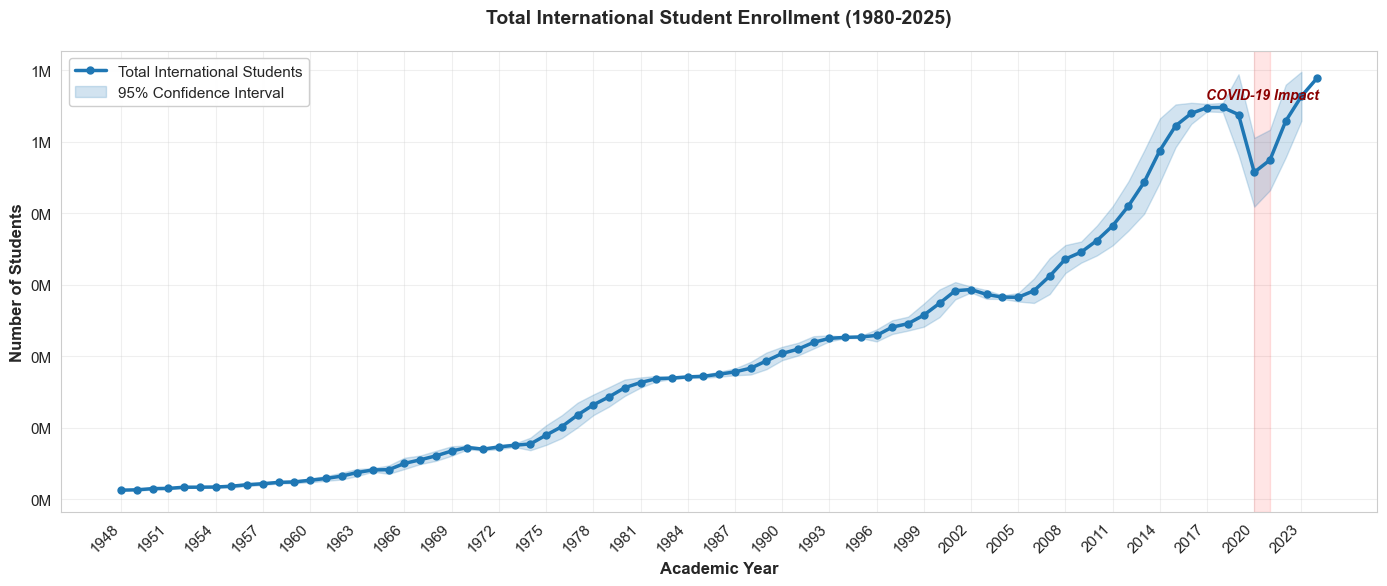

Chart saved: Total_students_trend_ci.png


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11


fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data - Extract starting year from format like '1949/50'
df_plot = df_Table1.copy()
df_plot['Year_numeric'] = df_plot["Year"].astype(str).str.split('/').str[0].astype(int)
x_data = df_plot['Year_numeric']
y_data = df_plot["Total int'l students"]

# Calculate rolling standard error for confidence interval
window = 3  # 3-year rolling window
rolling_std = y_data.rolling(window=window, center=True).std()
rolling_sem = rolling_std / np.sqrt(window)

# 95% confidence interval
ci_95 = 1.96 * rolling_sem

# Main trend line
ax.plot(x_data, y_data, linewidth=2.5, marker='o', markersize=5, 
        color='#1f77b4', label='Total International Students', zorder=3)

# Confidence interval band
ax.fill_between(x_data, 
                y_data - ci_95, 
                y_data + ci_95, 
                alpha=0.2, color='#1f77b4', label='95% Confidence Interval', zorder=2)

# Highlight COVID impact (2020-21)
covid_start = 2020
covid_end = 2021
ax.axvspan(covid_start, covid_end, alpha=0.1, color='red', zorder=1)
ax.text(2020.5, y_data.max() * 0.95, 'COVID-19 Impact', 
        ha='center', fontsize=10, style='italic', color='darkred', weight='bold')

# Formatting
ax.set_title('Total International Student Enrollment (1980-2025)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Academic Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Students', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

# Format y-axis as millions
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6)}M'))

# Rotate x labels for better readability
plt.xticks(rotation=45, ha='right')
year_ticks = np.arange(x_data.min(), x_data.max() + 1, 3)
ax.set_xticks(year_ticks)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Total_students_trend_ci.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: Total_students_trend_ci.png")


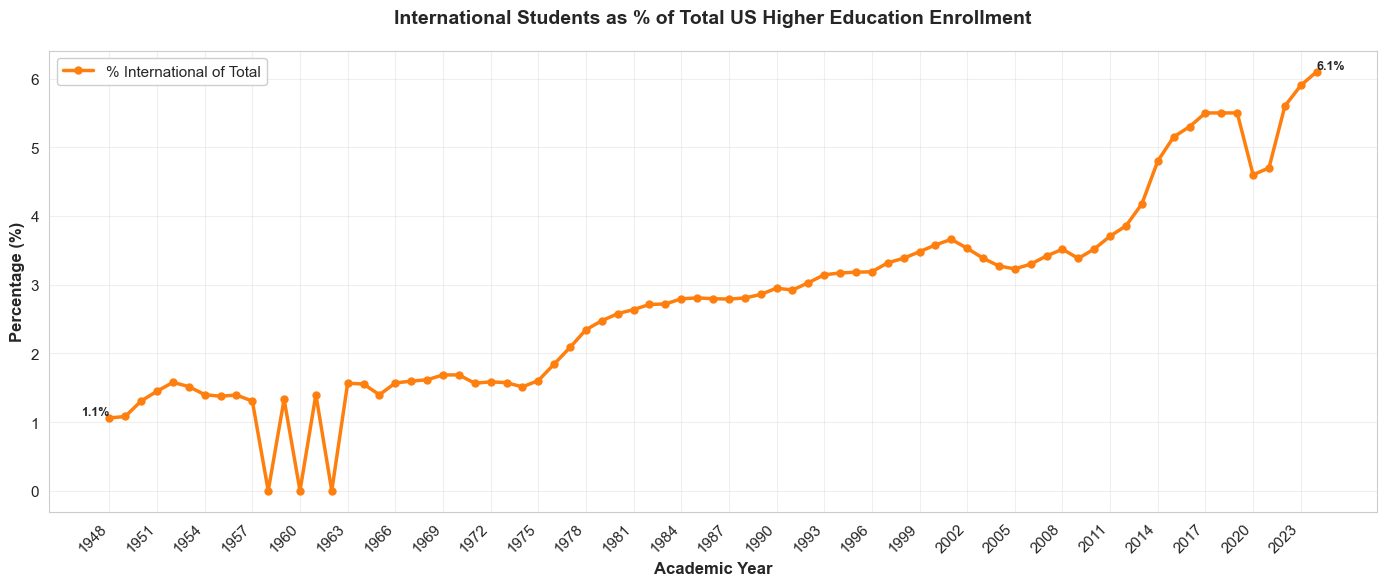

Chart saved: Percentage_enrollment_trend.png


In [19]:
fig, ax = plt.subplots(figsize=(14, 6))

x_data = df_plot['Year_numeric']
y_data = df_plot["% int'l"]

# Main trend line
ax.plot(x_data, y_data, linewidth=2.5, marker='o', markersize=5, 
        color='#ff7f0e', label='% International of Total', zorder=3)

# Add data labels on endpoints and key points
ax.text(x_data.iloc[0], y_data.iloc[0], f'{y_data.iloc[0]:.1f}%', 
        ha='right', va='bottom', fontsize=9, fontweight='bold')
ax.text(x_data.iloc[-1], y_data.iloc[-1], f'{y_data.iloc[-1]:.1f}%', 
        ha='left', va='bottom', fontsize=9, fontweight='bold')

# Formatting
ax.set_title('International Students as % of Total US Higher Education Enrollment', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Academic Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

plt.xticks(rotation=45, ha='right')
year_ticks = np.arange(x_data.min(), x_data.max() + 1, 3)
ax.set_xticks(year_ticks)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Percentage_enrollment_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: Percentage_enrollment_trend.png")

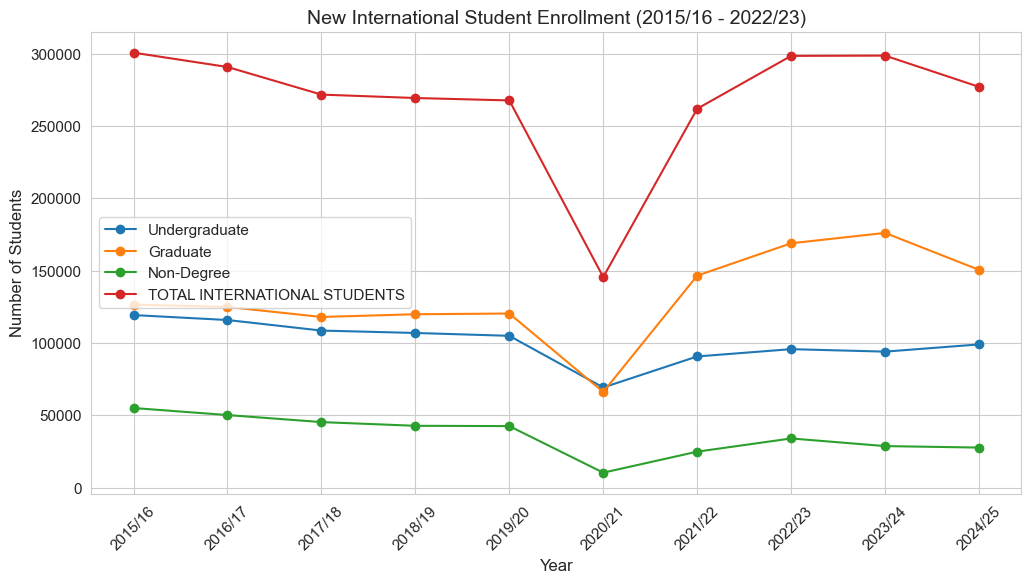

In [20]:
import matplotlib.pyplot as plt
import pandas as pd


year_cols = [col for col in df_Table2.columns if col != "% change from 2023/24" and col != "Category"]


for col in year_cols:
    df_Table2[col] = (df_Table2[col].astype(str).str.replace(",", "", regex=False).replace("-", pd.NA).astype(float))


plt.figure(figsize=(12,6))
for cat in ['Undergraduate', 'Graduate', 'Non-Degree', 'TOTAL INTERNATIONAL STUDENTS']:
    plt.plot(year_cols,df_Table2.loc[df_Table2['Category']==cat, year_cols].values.flatten(),marker='o',label=cat)

plt.title("New International Student Enrollment (2015/16 - 2022/23)")
plt.xlabel("Year")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.savefig('NEW INTERNATIONAL STUDENT ENROLLMENT.png', dpi=300, bbox_inches='tight')
plt.show()


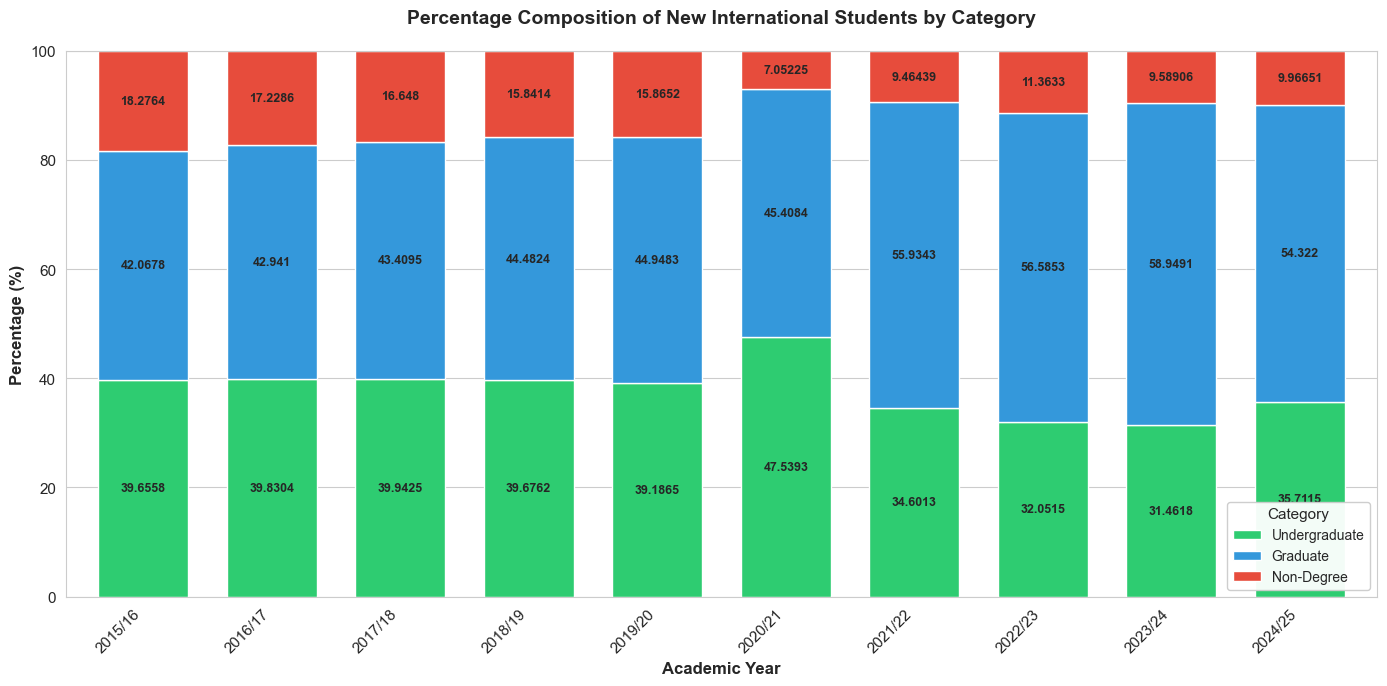

✓ Chart saved: Composition_stacked_bar.png


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set professional style
sns.set_style("whitegrid")

# Get year columns from Table 2
year_cols = [col for col in df_Table2.columns 
             if col not in ["% change from 2023/24", "Category"] and col != "Unnamed: 0"]

# Define categories and colors
categories_to_plot = ['Undergraduate', 'Graduate', 'Non-Degree']
colors_comp = ['#2ecc71', '#3498db', '#e74c3c']

# Calculate percentages
df_percent_comp = df_Table2.copy()

for col in year_cols:
    total = df_Table2.loc[df_Table2['Category'] == 'TOTAL INTERNATIONAL STUDENTS', col].values[0]
    df_percent_comp[col] = (df_Table2[col] / total) * 100

# Filter and reshape data
df_percent_cats = df_percent_comp[df_percent_comp['Category'].isin(categories_to_plot)].copy()
df_plot = df_percent_cats.set_index('Category')[year_cols].T

# Create chart
fig, ax = plt.subplots(figsize=(14, 7))

df_plot.plot(kind='bar', stacked=True, ax=ax, color=colors_comp, width=0.7)

ax.set_title('Percentage Composition of New International Students by Category', 
            fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Academic Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.legend(title='Category', fontsize=10, loc='lower right', framealpha=0.95)
ax.set_ylim(0, 100)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=9, weight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Composition_stacked_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved: Composition_stacked_bar.png")

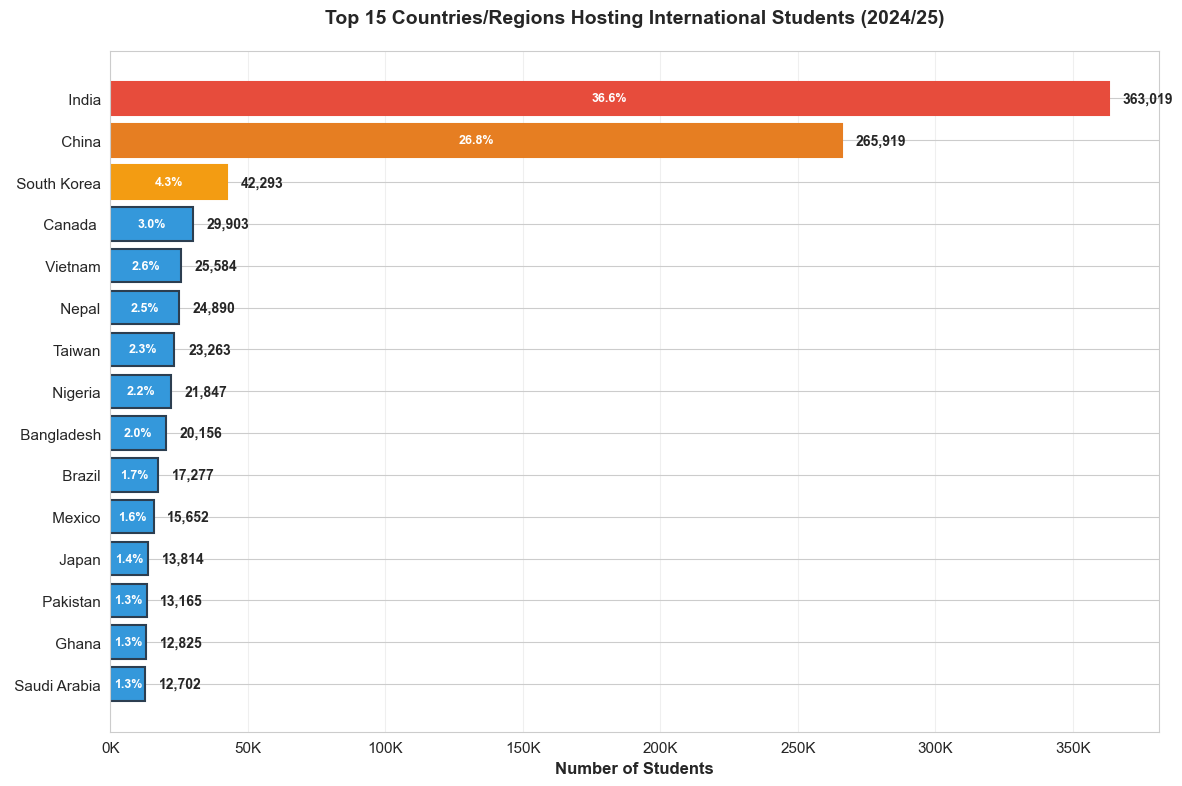

In [22]:
top_countries = df_Table5.nlargest(15, 'Total Intl Students')[['Place of Origin', 'Total Intl Students']]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(range(len(top_countries)), top_countries['Total Intl Students'].values, 
               color='#3498db', edgecolor='#2c3e50', linewidth=1.5)

# Color top 3 differently
bars[0].set_color('#e74c3c')  # Red for #1
bars[1].set_color('#e67e22')  # Orange for #2
bars[2].set_color('#f39c12')  # Yellow for #3

# Add data labels
for i, (idx, row) in enumerate(top_countries.iterrows()):
    ax.text(row['Total Intl Students'] + 5000, i, f"{int(row['Total Intl Students']):,}", 
           va='center', fontsize=10, fontweight='bold')
    # Add percentage of total
    pct = (row['Total Intl Students'] / df_Table5['Total Intl Students'].sum()) * 100
    ax.text(row['Total Intl Students']/2, i, f'{pct:.1f}%', 
           va='center', ha='center', fontsize=9, color='white', fontweight='bold')

ax.set_yticks(range(len(top_countries)))
ax.set_yticklabels(top_countries['Place of Origin'].values, fontsize=11)
ax.set_xlabel('Number of Students', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Countries/Regions Hosting International Students (2024/25)', 
            fontsize=14, fontweight='bold', pad=20)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3)}K'))
ax.grid(True, alpha=0.3, axis='x')

# Invert y-axis so #1 is at top
ax.invert_yaxis()
plt.savefig('Top_15_Countries_Regions_Hosting_International_Students_2024_2025.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [23]:
df_institutions = pd.concat(
    [df_Table12, df_Table13, df_Table14, df_Table15],
    keys=["Doctoral", "Master", "Baccalaureate", "Associate"],
    names=["Institution Type"]
).reset_index(level=0)
df_institutions.head()

,Institution Type,Institution,City,State,Total International Students
0,Doctoral,New York University,New York,NY,27532
1,Doctoral,Northeastern University - Boston,Boston,MA,22465
2,Doctoral,Columbia University,New York,NY,20733
3,Doctoral,Arizona State University - Campus Immersion,Tempe,AZ,20368
4,Doctoral,University of Southern California,Los Angeles,CA,17884


In [24]:
df_institutions.groupby("Institution Type")["Total International Students"].sum()

Institution Type
Associate         38036
Baccalaureate     17731
Doctoral         427310
Master            83526
Name: Total International Students, dtype: object

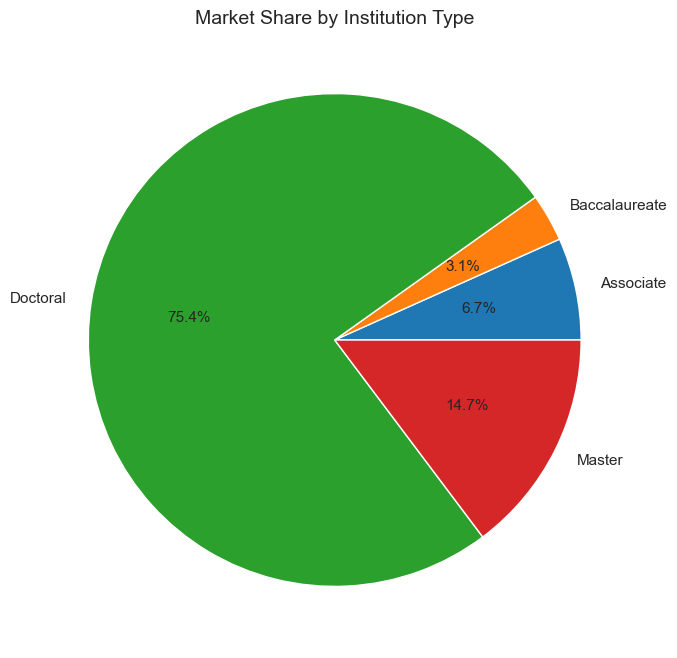

In [25]:
total_students = df_institutions["Total International Students"].sum()

df_share = (
    df_institutions
    .groupby("Institution Type")["Total International Students"]
    .sum()
    .reset_index()
)

df_share["Market Share (%)"] = (df_share["Total International Students"] / total_students) * 100

plt.figure(figsize=(8,8))
plt.pie(
    df_share["Market Share (%)"],
    labels=df_share["Institution Type"],
    autopct="%1.1f%%"
)

plt.title("Market Share by Institution Type")
plt.savefig('MARKET SHARE BY INSTITUTION TYPE.png', dpi=300, bbox_inches='tight')
plt.show()


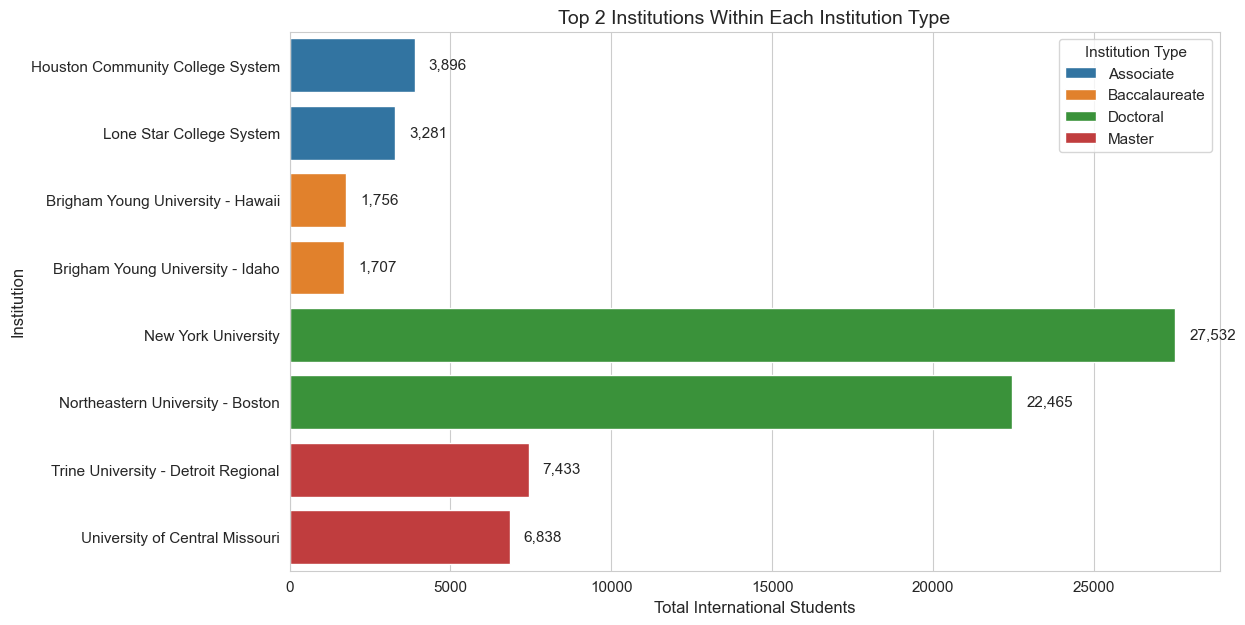

In [26]:
top2_each_type = (
    df_institutions
    .sort_values(["Institution Type", "Total International Students"], ascending=[True, False])
    .groupby("Institution Type")
    .head(2)
)

top2_each_type


plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=top2_each_type,
    x="Total International Students",
    y="Institution",
    hue="Institution Type",
    dodge=False
)

plt.title("Top 2 Institutions Within Each Institution Type")
plt.xlabel("Total International Students")
plt.ylabel("Institution")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=10)

plt.legend(title="Institution Type")
plt.savefig('TOP_2_COUNTRIES_IN_INSTITUTION_TYPE.png', dpi=300, bbox_inches='tight')
plt.show()


  Institution Type       Mean  Median      Std Dev  Skewness
0         Research  10682.750  8911.5  4933.146755  1.752021
1           Master   2088.150  1474.0  1565.410629  2.068853
2    Baccalaureate    443.275   352.0   313.371982  3.563038
3        Associate    950.900   590.5   844.719368  2.009896


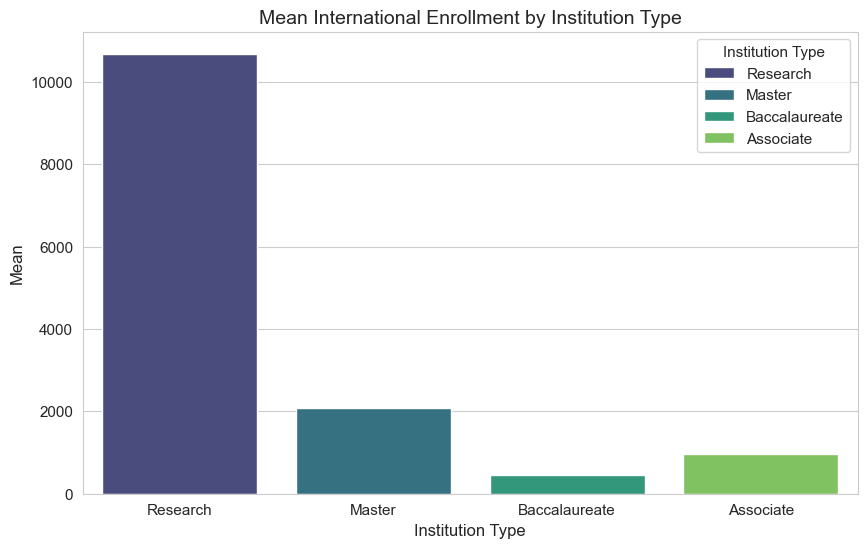

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# Combine institutional tables (if not already combined)
institution_tables = {
    "Research": df_Table12,
    "Master": df_Table13,
    "Baccalaureate": df_Table14,
    "Associate": df_Table15
}

from scipy.stats import skew

stats_list = []

for name, df in institution_tables.items():
    
    values = df["Total International Students"]
    values = pd.to_numeric(values.astype(str).str.replace(",", ""), errors="coerce")
    values = values.dropna()
    
    stats_list.append({
        "Institution Type": name,
        "Mean": values.mean(),
        "Median": values.median(),
        "Std Dev": values.std(),
        "Skewness": skew(values)
    })


stats_df = pd.DataFrame(stats_list)
print(stats_df)

# Visual comparison
plt.figure(figsize=(10,6))
sns.barplot(data=stats_df, x="Institution Type", y="Mean",hue="Institution Type",palette="viridis",legend=True)
plt.title("Mean International Enrollment by Institution Type")
plt.savefig('MEAN_INTERNATIONAL_ENROLLMENT_BY_INSTITUTION_TYPE.png', dpi=300, bbox_inches='tight')
plt.show()


<b>Central Tendency</b>: The Mean and Median calculations highlight a significant disparity between institutional types. For example, Research institutions show a mean enrollment of 10,682.75, which is roughly five times higher than Master’s institutions (2,088.15).

<b> Dispersion and Skewness </b>: The analysis calculates Standard Deviation and Skewness to measure data spread and asymmetry.
1. Research Institutions show a skewness of 1.75, indicating a right-skewed distribution where a few schools host significantly more students than the average.
2. Baccalaureate Institutions exhibit the highest skewness (3.56), suggesting an extremely uneven distribution within that specific category.

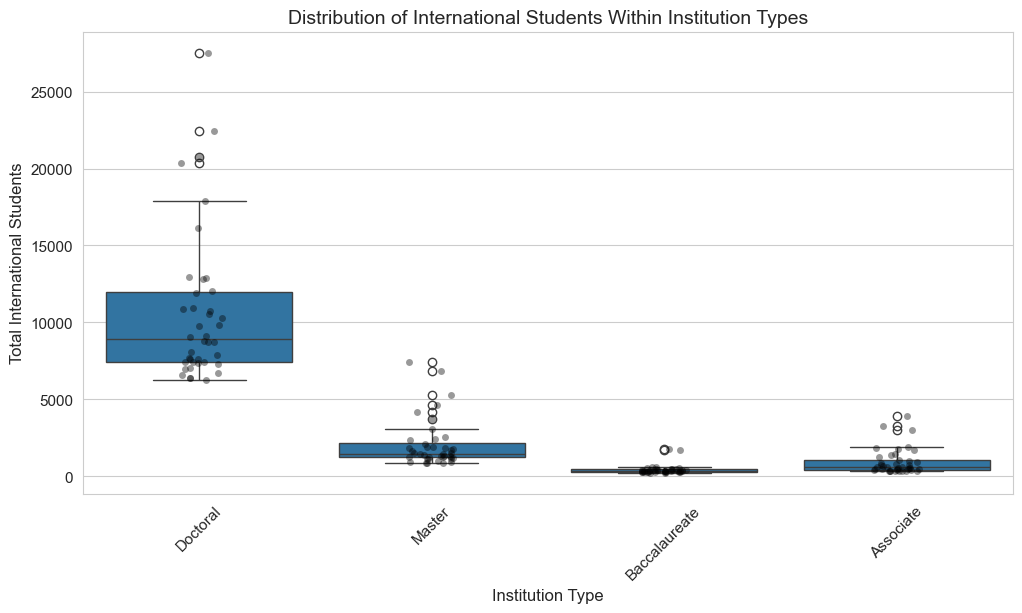

Chart saved: 06_boxplot_institution_type.png


In [28]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_institutions,
    x="Institution Type",
    y="Total International Students"
)

sns.stripplot(
    data=df_institutions,
    x="Institution Type",
    y="Total International Students",
    color="black",
    alpha=0.4,
    legend=True
)

plt.xticks(rotation=45)
plt.title("Distribution of International Students Within Institution Types")
plt.savefig('Boxplot_institution_type.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: 06_boxplot_institution_type.png")


The combined boxplot and stripplot reveal a highly asymmetrical distribution of international stdents within institutional tiers. While Doctoral institutions represent the highest capacity for enrollment, they also exhibit the most significant internal variance, with individual 'powerhouse' schols acting as extreme statistical outliers exceding 25,000 students. This visualization confirms that mean-based comparisons are heavily influenced by these outliers, necessitating the use of non-parametric measures like the Gini Coefficient to accurately describe market concentration.

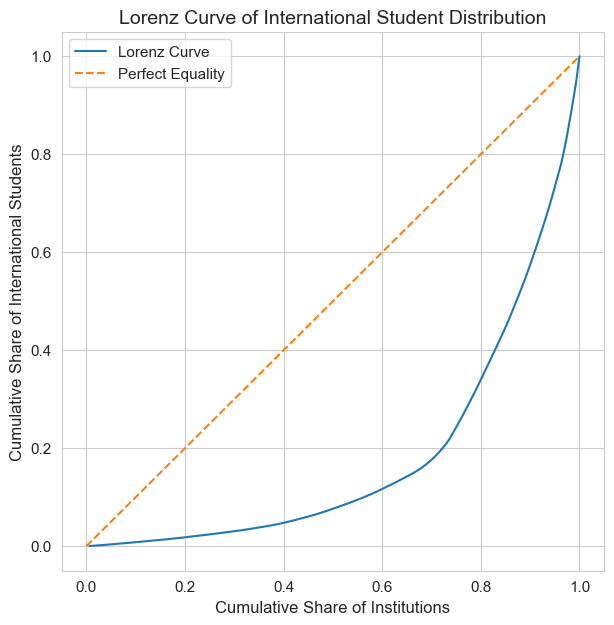

In [29]:
import numpy as np

values = np.sort(df_institutions["Total International Students"].values)
cumvals = np.cumsum(values)
cumvals = cumvals / cumvals[-1]
cumprop = np.arange(1, len(values)+1) / len(values)

plt.figure(figsize=(7,7))
plt.plot(cumprop, cumvals, label="Lorenz Curve")
plt.plot([0,1],[0,1], linestyle="--", label="Perfect Equality")

plt.xlabel("Cumulative Share of Institutions")
plt.ylabel("Cumulative Share of International Students")
plt.title("Lorenz Curve of International Student Distribution")
plt.savefig('LORENZ_CURVE_INTERNATIONAL_STUDENT_DISTRIBUTION.png', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()


# Lorenz Curve Analysis: International Student Distribution

As shown in the figure, the Lorenz curve illustrates a significant degree of inequality in how international students are distributed across U.S. institutions.

<b> Relationship to Perfect Equality </b> : The solid blue Lorenz curve bows significantly away from the dashed orange "Line of Perfect Equality". This gap indicates that a small percentage of institutions host a disproportionately large share of the total international student population.

<b> Concentration Insights </b> : By observing the curvature, it is evident that approximately 70% of institutions account for less than 20% of the cumulative share of international students. Conversely, the steepest part of the curve at the far right indicates that the top 10% to 20% of institutions host the vast majority of these students.

In [30]:
gini = 1 - 2 * np.trapezoid(cumvals, cumprop)
print("Gini Coefficient:", round(gini, 4))

Gini Coefficient: 0.6344


<b> Gini Coefficient </b> : The calculated Gini Coefficient is 0.634. Thsi confirms a high level of concentration, suggesting that international enrollment is not broadly distributed but is instead concentrated within specific "powerhouse" institutions.

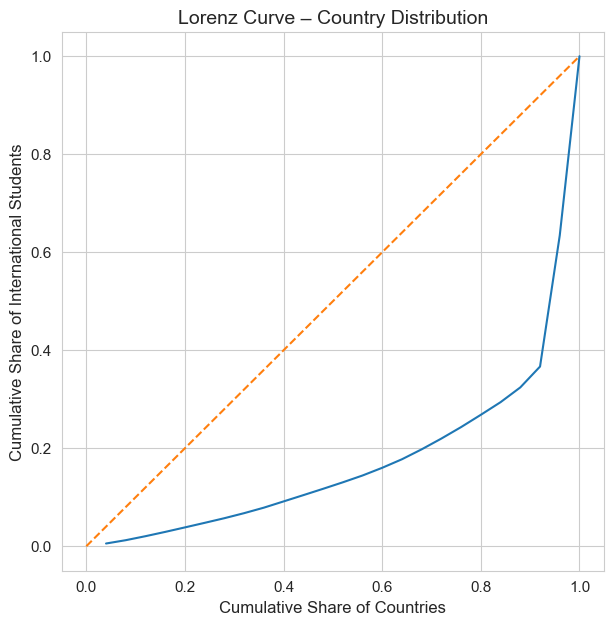

Gini (Institutions): 0.6344
Gini (Countries): 0.6538


<Figure size 1400x600 with 0 Axes>

In [31]:
df_sorted = df_Table5.sort_values("Total Intl Students")
cum_students = df_sorted["Total Intl Students"].cumsum()
cum_students_share = cum_students / cum_students.iloc[-1]
cum_country_share = np.arange(1, len(df_sorted)+1) / len(df_sorted)

plt.figure(figsize=(7,7))
plt.plot(cum_country_share, cum_students_share)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("Lorenz Curve – Country Distribution")
plt.xlabel("Cumulative Share of Countries")
plt.ylabel("Cumulative Share of International Students")
plt.show()


def gini_coefficient(x):
    x = np.sort(x)
    n = len(x)
    cumulative = np.cumsum(x)
    return 1 - 2 * np.trapezoid(cumulative / cumulative[-1], dx=1/n)

# Institutional Gini
gini_institutions = gini_coefficient(df_institutions["Total International Students"])

# Country Gini
gini_countries = gini_coefficient(df_Table5["Total Intl Students"])
plt.savefig('LORENZ_CURVE_COUNTRY_DISTRIBUTION.png', dpi=300, bbox_inches='tight')
print("Gini (Institutions):", round(gini_institutions, 4))
print("Gini (Countries):", round(gini_countries, 4))


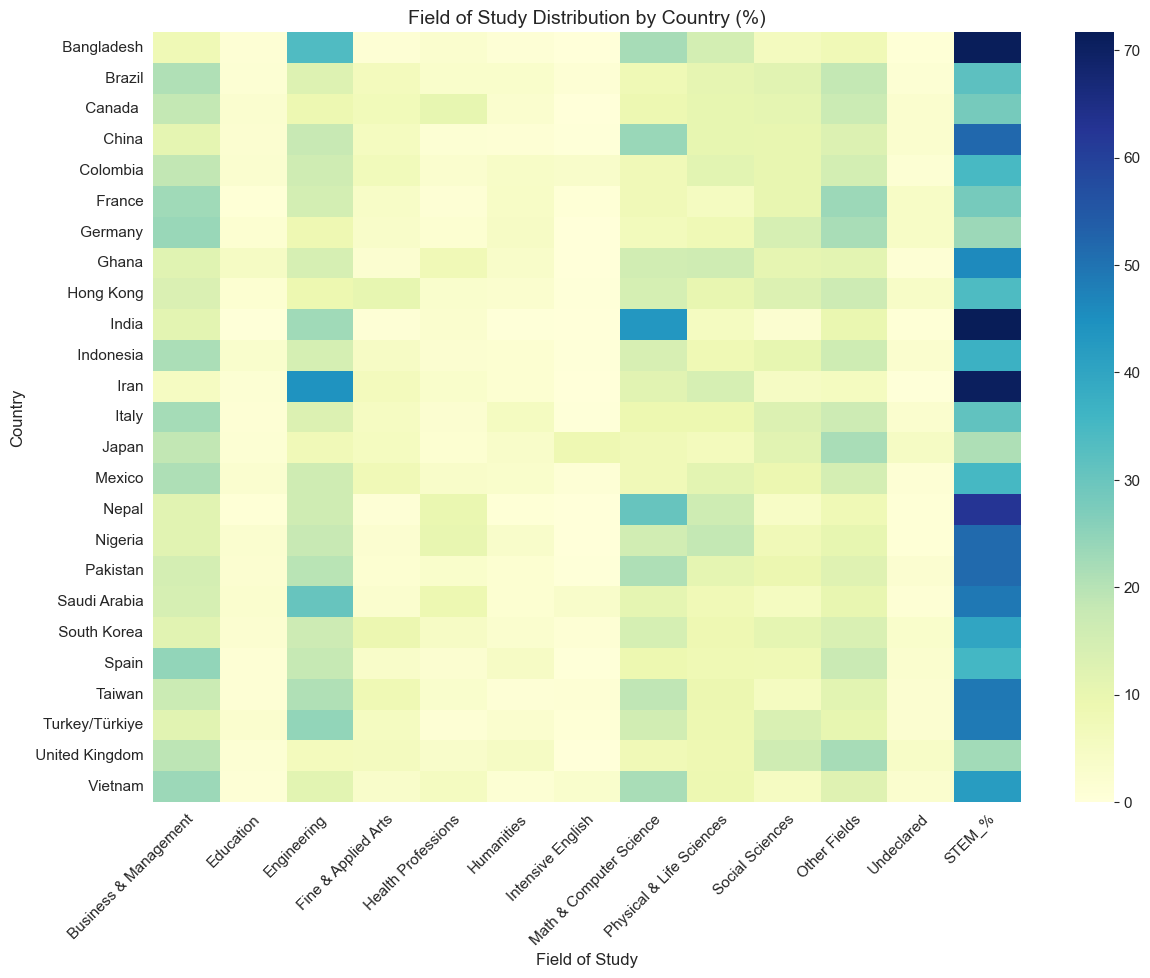

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

df_Table5["STEM_%"] = (
    df_Table5["Engineering"] +
    df_Table5["Math & Computer Science"] +
    df_Table5["Physical & Life Sciences"]
)
# Exclude total column
field_cols = df_Table5.columns.drop(["Place of Origin", "Total Intl Students"])

plt.figure(figsize=(14,10))

sns.heatmap(
    df_Table5.set_index("Place of Origin")[field_cols],
    cmap="YlGnBu",
    annot=False
)
plt.xticks(
    rotation=45,
    ha="right",   # aligns labels better under columns
    rotation_mode="anchor"
)

plt.title("Field of Study Distribution by Country (%)")
plt.ylabel("Country")
plt.xlabel("Field of Study")
plt.xticks(rotation=45)
plt.savefig('Fields_of_Study_Distribution_by_Country.png', dpi=300, bbox_inches='tight')
plt.show()


The heatmap identifies clear academic specializations based on a student's place of origin:

<b>STEM Dominance</b>: India and Iran show the highest concentration in Math & Computer Science and Engineering, respectively, as evidenced by the darkest blue clusters in those columns.

<b>Business & Management</b>: This field shows broad global appeal, with moderate to high density (medium blue) across nearly every country listed, particularly Canada, Japan, and Mexico.

<b>Niche Fields</b>: Areas like Education and Humanities show very light shading across the board, indicating they are not primary drivers for international student enrollment in the current market.

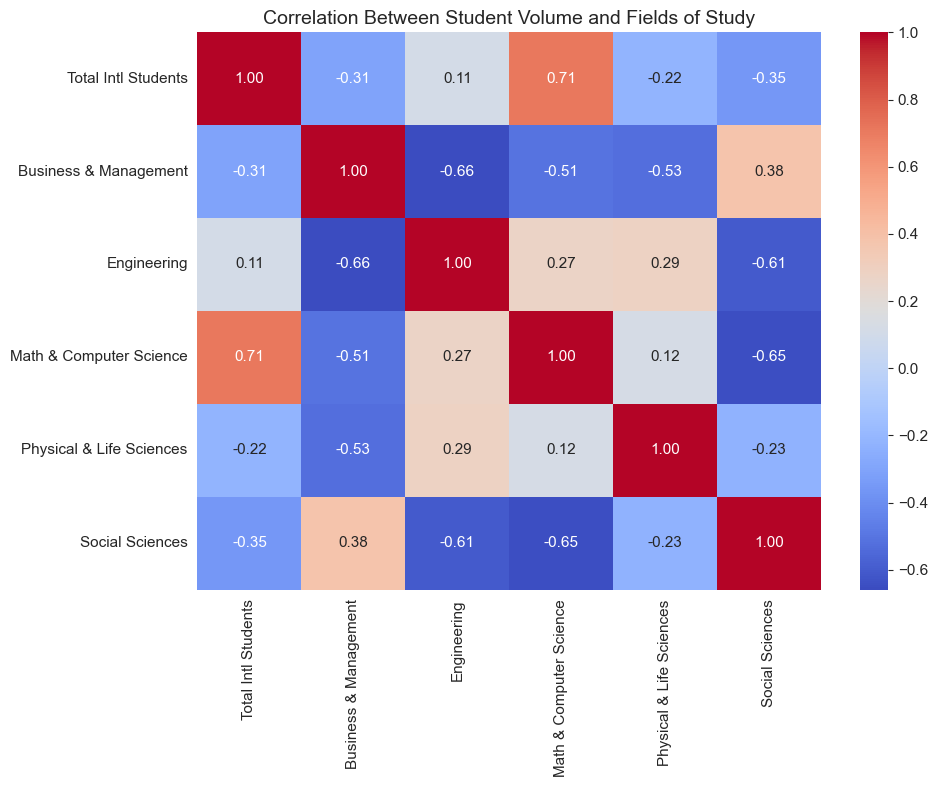

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting relevant features from Table 5 (Field of Study by Origin)
corr_features = ['Total Intl Students', 'Business & Management', 'Engineering', 
                 'Math & Computer Science', 'Physical & Life Sciences', 'Social Sciences']
corr_data = df_Table5[corr_features].corr()

# Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Student Volume and Fields of Study')
plt.tight_layout()
plt.savefig('CORRELATION_BETWEEN_STUDENT_VOLUME_FIELDS_OF_STUDY.png', dpi=300, bbox_inches='tight')
plt.show()

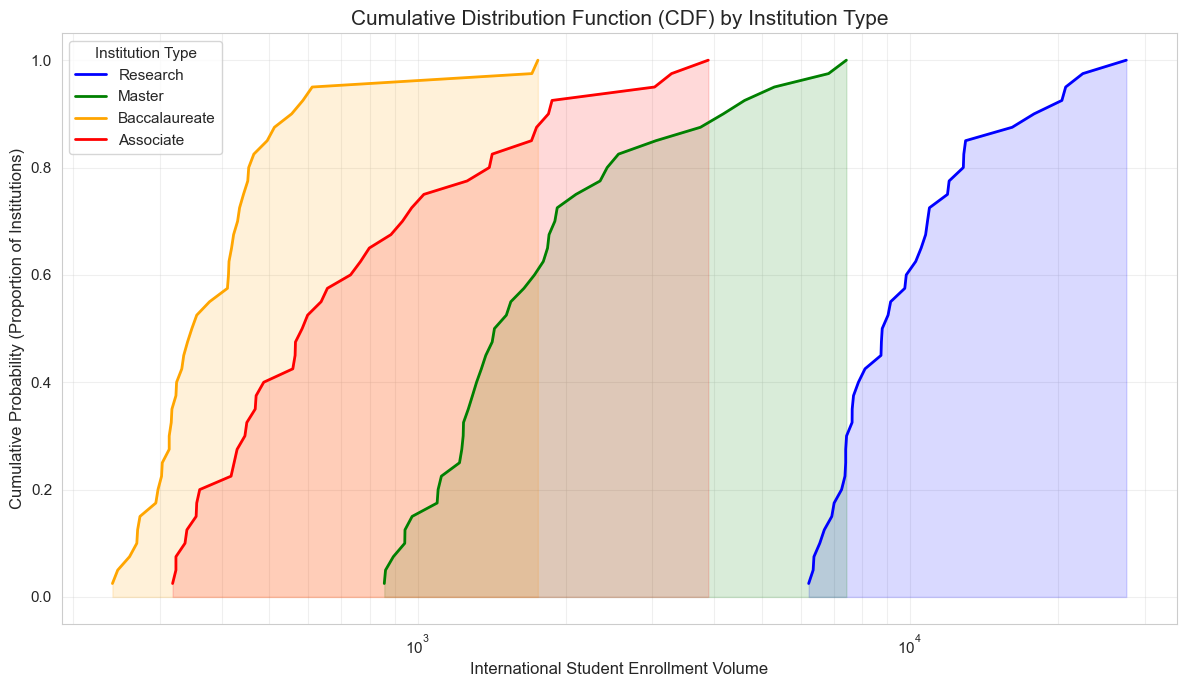

In [34]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Define colors for consistency in your PPT
colors = {
    "Research": "blue",
    "Master": "green",
    "Baccalaureate": "orange",
    "Associate": "red"
}

for name, df in institution_tables.items():
    # 1. Extract and Clean Data
    values = pd.to_numeric(df["Total International Students"].astype(str).str.replace(",", ""), errors="coerce")
    data_sorted = np.sort(values.dropna())
    
    # 2. Calculate CDF coordinates
    # x-axis: Number of students
    # y-axis: Proportion of schools with <= x students
    y = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    
    # 3. Plot each line
    plt.plot(data_sorted, y, label=name, color=colors[name], linewidth=2)

    plt.fill_between(data_sorted,y,alpha=0.15,color=colors[name])

# Formatting for your Capstone Report
plt.title('Cumulative Distribution Function (CDF) by Institution Type', fontsize=15)
plt.xlabel('International Student Enrollment Volume', fontsize=12)
plt.ylabel('Cumulative Probability (Proportion of Institutions)', fontsize=12)
plt.xscale('log')  # Recommended: Log scale helps see small schools and large schools clearly on one axis
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(title="Institution Type")


plt.tight_layout()
plt.savefig('CDF_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


1. Academic Composition Pie Chart (Table 3)
--------------------------------------------------------------------------------


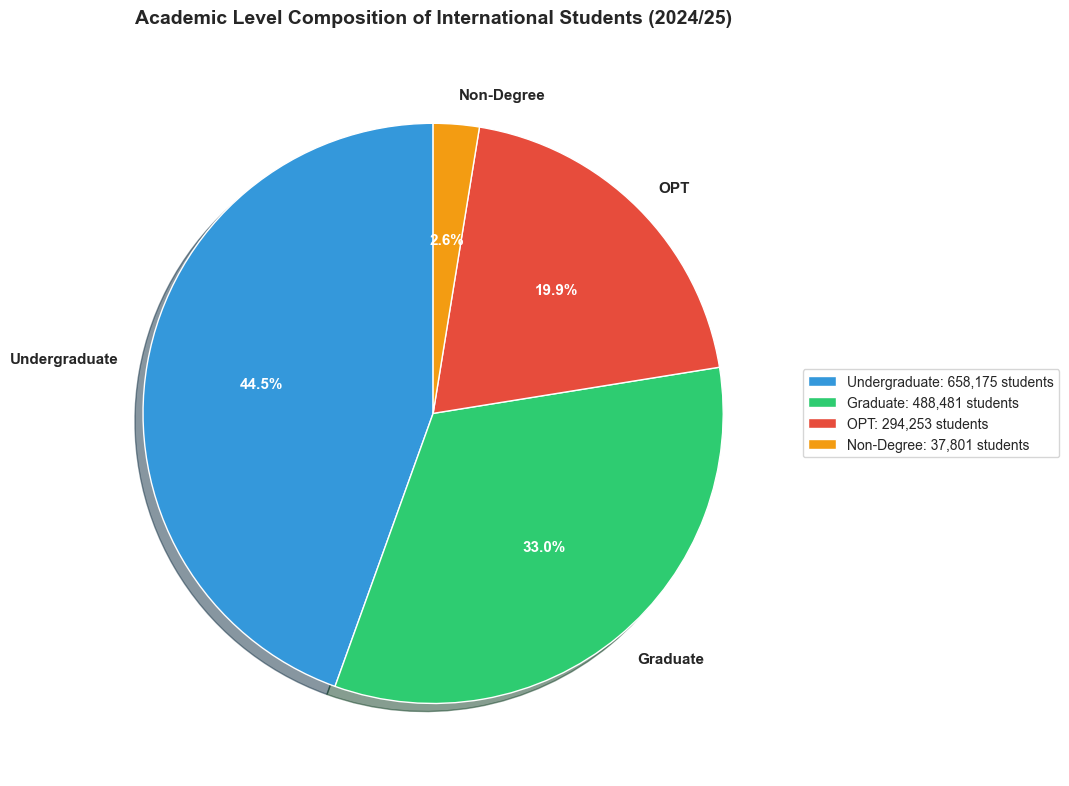

Chart saved: Academic_composition_pie.png
  Breakdown:
    Undergraduate           658,175  ( 44.5%)
    Graduate                488,481  ( 33.0%)
    OPT                     294,253  ( 19.9%)
    Non-Degree               37,801  (  2.6%)


In [35]:
print('\n1. Academic Composition Pie Chart (Table 3)')
print('-'*80)

# Get data from Table 3 by Category
academic_data = df_Table3.groupby('Category')['2024/25 (N)'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for categories
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

# Create pie chart
wedges, texts, autotexts = ax.pie(academic_data.values,labels=academic_data.index,autopct='%1.1f%%',startangle=90,colors=colors,
                                    textprops={'fontsize': 11, 'weight': 'bold'},
                                    shadow=True)

# Enhance autotext (percentage labels)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

# Add title
ax.set_title('Academic Level Composition of International Students (2024/25)', 
             fontsize=14, fontweight='bold', pad=20)

# Add legend with values
legend_labels = [f'{cat}: {int(val):,} students' for cat, val in academic_data.items()]
ax.legend(legend_labels, fontsize=10, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.savefig('Academic_composition_pie.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart saved: Academic_composition_pie.png")
print(f"  Breakdown:")
for cat, val in academic_data.items():
    pct = (val / academic_data.sum()) * 100
    print(f"    {cat:20} {int(val):>10,}  ({pct:5.1f}%)")


2. Regional Distribution Pie Chart (Table 7)
--------------------------------------------------------------------------------


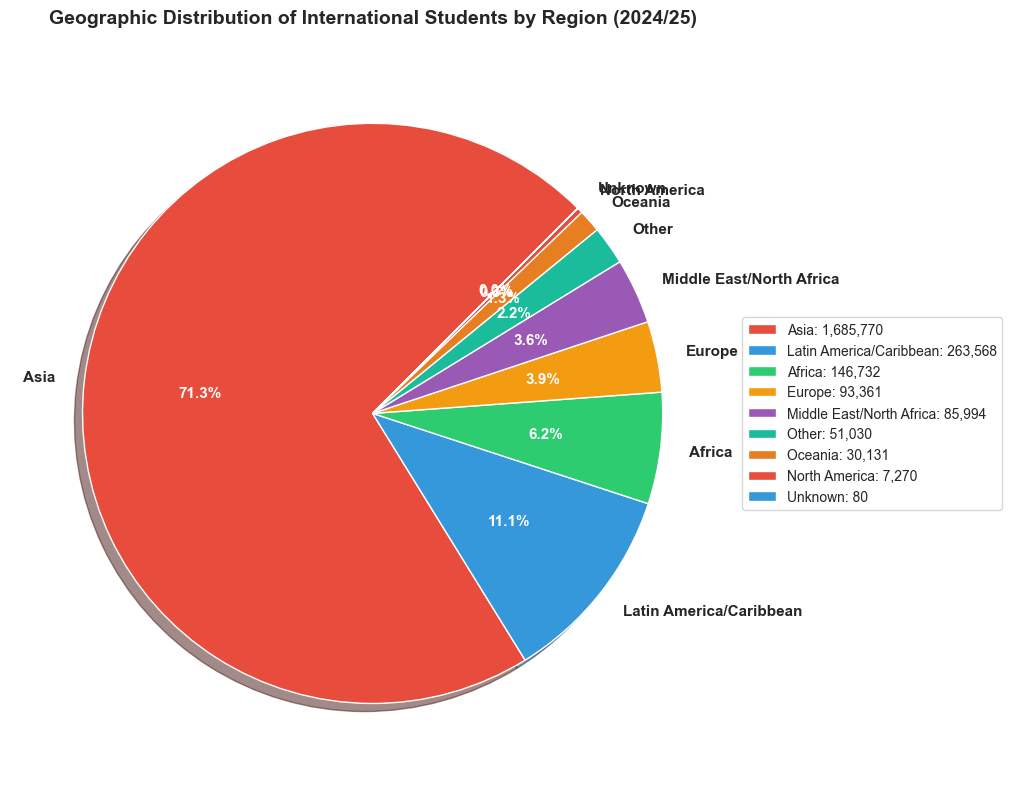

Chart saved: Regional_distribution_pie.png


In [36]:
print('\n2. Regional Distribution Pie Chart (Table 7)')
print('-'*80)

# Get regional data from Table 7
regional_data = df_Table7.groupby('Region')['2024/25'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

colors_region = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

wedges, texts, autotexts = ax.pie(regional_data.values,
                                    labels=regional_data.index,
                                    autopct='%1.1f%%',
                                    startangle=45,
                                    colors=colors_region[:len(regional_data)],
                                    textprops={'fontsize': 11, 'weight': 'bold'},
                                    shadow=True)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

ax.set_title('Geographic Distribution of International Students by Region (2024/25)', 
             fontsize=14, fontweight='bold', pad=20)

legend_labels_region = [f'{region}: {int(val):,}' for region, val in regional_data.items()]
ax.legend(legend_labels_region, fontsize=10, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.savefig('Regional_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart saved: Regional_distribution_pie.png")

Creating scatter plot...


C:\Users\madan\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


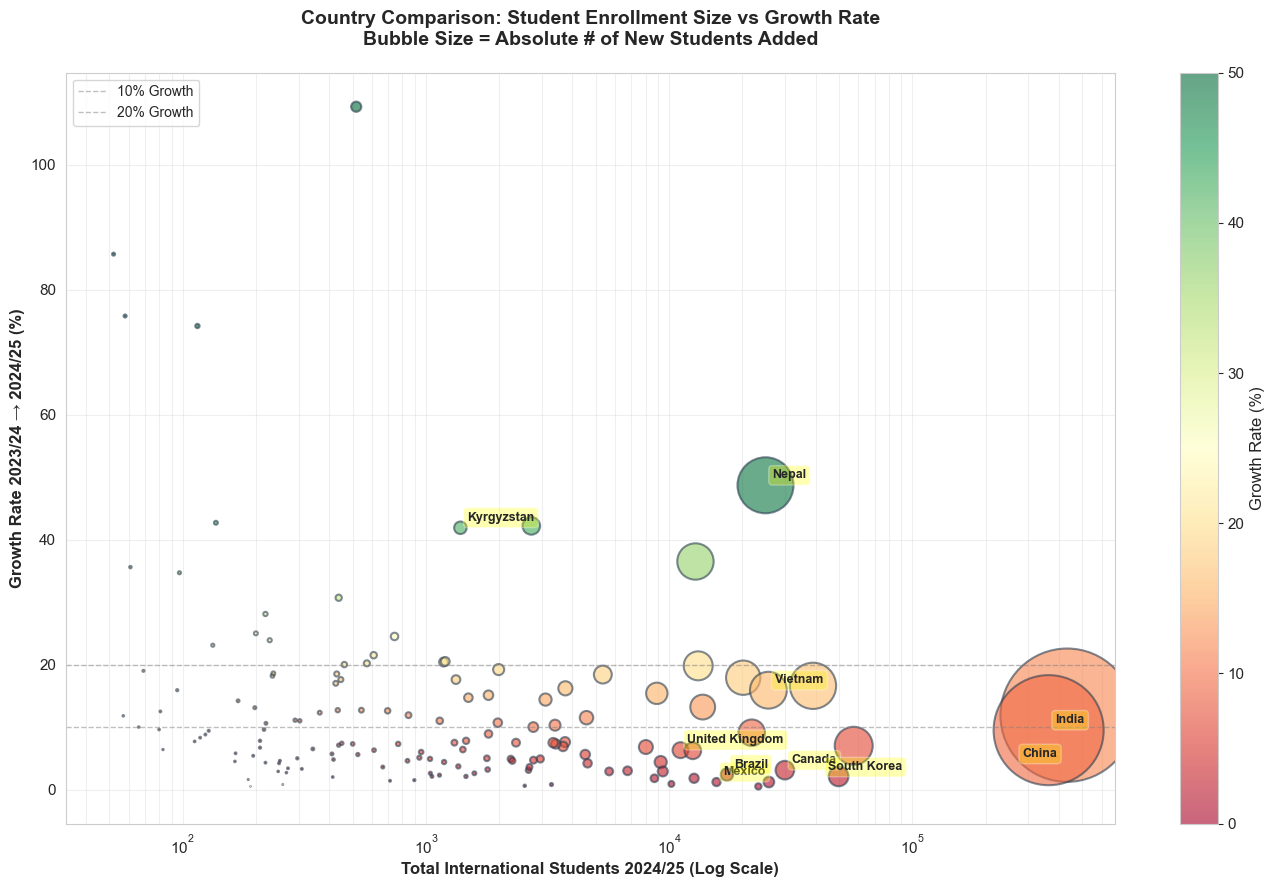

Chart saved: scatter_enrollment_vs_growth.png

KEY INSIGHTS - Normalized by Base Size:

India:
  2024/25 Enrollment:  363,019 students
  Growth Rate:     9.5%
  Absolute Growth: 31,417 new students

Kyrgyzstan:
  2024/25 Enrollment:    1,386 students
  Growth Rate:    41.9%
  Absolute Growth:    409 new students

Nepal:
  2024/25 Enrollment:   24,890 students
  Growth Rate:    48.7%
  Absolute Growth:  8,148 new students

China:
  2024/25 Enrollment:  265,919 students
  Growth Rate:     4.1%
  Absolute Growth: -11,479 new students

Vietnam:
  2024/25 Enrollment:   25,584 students
  Growth Rate:    15.9%
  Absolute Growth:  3,518 new students


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Use existing df_Table7 (already loaded in your notebook)

# Calculate absolute growth
df_Table7['Students_2024'] = pd.to_numeric(df_Table7['2024/25'], errors='coerce')
df_Table7['Students_2023'] = pd.to_numeric(df_Table7['2023/24'], errors='coerce')
df_Table7['Absolute_Growth'] = df_Table7['Students_2024'] - df_Table7['Students_2023']
df_Table7['Growth_Pct'] = pd.to_numeric(df_Table7['% Change'].astype(str).str.replace('%', ''), errors='coerce')

# Filter out regions (all caps) and keep only countries with data
df_scatter = df_Table7[
    (~df_Table7['Place of Origin'].str.isupper()) & 
    (df_Table7['Students_2024'] >= 50) &
    (df_Table7['Growth_Pct'].notna())
].copy()

print("Creating scatter plot...")

# Create scatter plot
fig, ax = plt.subplots(figsize=(14, 9))

scatter = ax.scatter(df_scatter['Students_2024'], 
                     df_scatter['Growth_Pct'],
                     s=df_scatter['Absolute_Growth']/5,
                     alpha=0.6,
                     c=df_scatter['Growth_Pct'],
                     cmap='RdYlGn',
                     edgecolors='#2c3e50',
                     linewidth=1.5,
                     vmin=0,
                     vmax=50)

# Highlight key countries
key_countries = ['India', 'China', 'Mexico', 'Nepal', 'Kyrgyzstan', 'Vietnam', 
                'Canada', 'United Kingdom', 'Brazil', 'South Korea']

for country in key_countries:
    country_data = df_scatter[df_scatter['Place of Origin'] == country]
    if not country_data.empty:
        row = country_data.iloc[0]
        ax.annotate(country, 
                   xy=(row['Students_2024'], row['Growth_Pct']),
                   xytext=(5, 5),
                   textcoords='offset points',
                   fontsize=9,
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

# Set log scale for x-axis
ax.set_xscale('log')

ax.set_xlabel('Total International Students 2024/25 (Log Scale)', fontsize=12, fontweight='bold')
ax.set_ylabel('Growth Rate 2023/24 → 2024/25 (%)', fontsize=12, fontweight='bold')
ax.set_title('Country Comparison: Student Enrollment Size vs Growth Rate\n' + 
            'Bubble Size = Absolute # of New Students Added',
            fontsize=14, fontweight='bold', pad=20)

cbar = plt.colorbar(scatter, ax=ax, label='Growth Rate (%)')
ax.grid(True, alpha=0.3, which='both')

ax.axhline(y=10, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='10% Growth')
ax.axhline(y=20, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='20% Growth')

ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('scatter_enrollment_vs_growth.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: scatter_enrollment_vs_growth.png")

# Show key examples
print("\n" + "="*80)
print("KEY INSIGHTS - Normalized by Base Size:")
print("="*80)

examples = ['India', 'Kyrgyzstan', 'Nepal', 'China', 'Vietnam']

for country_name in examples:
    country_data = df_scatter[df_scatter['Place of Origin'] == country_name]
    if not country_data.empty:
        row = country_data.iloc[0]
        print(f"\n{country_name}:")
        print(f"  2024/25 Enrollment: {int(row['Students_2024']):>8,} students")
        print(f"  Growth Rate: {row['Growth_Pct']:>7.1f}%")
        print(f"  Absolute Growth: {int(row['Absolute_Growth']):>6,} new students")


5. Funding Source Distribution Pie Chart (Table 10)
--------------------------------------------------------------------------------


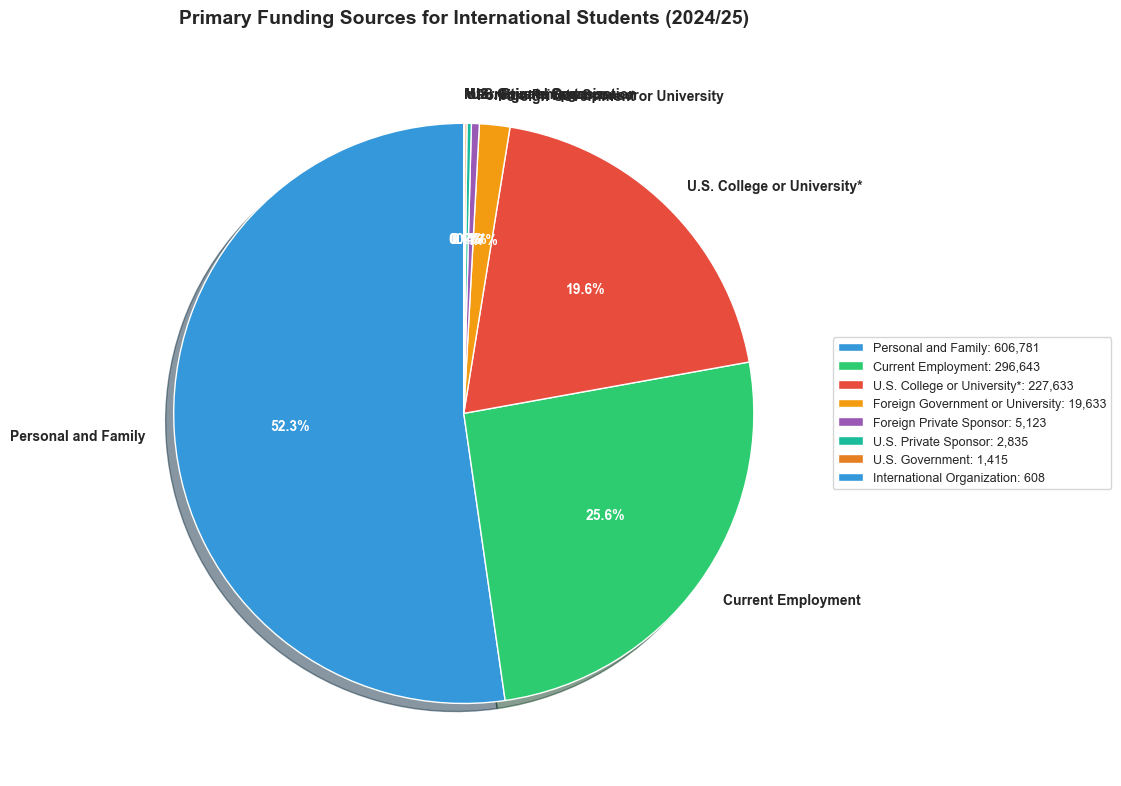

Chart saved: Funding_source_distribution_pie.png

  Funding breakdown:
    Personal and Family                    606,781  ( 52.3%)
    Current Employment                     296,643  ( 25.6%)
    U.S. College or University*            227,633  ( 19.6%)
    Foreign Government or University        19,633  (  1.7%)
    Foreign Private Sponsor                  5,123  (  0.4%)
    U.S. Private Sponsor                     2,835  (  0.2%)
    U.S. Government                          1,415  (  0.1%)
    International Organization                 608  (  0.1%)


In [38]:
print('\n5. Funding Source Distribution Pie Chart (Table 10)')
print('-'*80)

# Get funding data
funding_data = df_Table10.set_index('Funding Source')['2024/25 (N)'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

colors_funding = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

wedges, texts, autotexts = ax.pie(funding_data.values,
                                    labels=funding_data.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    colors=colors_funding[:len(funding_data)],
                                    textprops={'fontsize': 10, 'weight': 'bold'},
                                    shadow=True)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

ax.set_title('Primary Funding Sources for International Students (2024/25)', 
             fontsize=14, fontweight='bold', pad=20)

legend_labels_funding = [f'{source}: {int(val):,}' for source, val in funding_data.items()]
ax.legend(legend_labels_funding, fontsize=9, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.savefig('Funding_source_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Chart saved: Funding_source_distribution_pie.png")
print(f"\n  Funding breakdown:")
for source, val in funding_data.items():
    pct = (val / funding_data.sum()) * 100
    print(f"    {source:35} {int(val):>10,}  ({pct:5.1f}%)")

<h1> TIME SERIES ANALYSIS</h1>

In [39]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import io
import sys

# Install Prophet if needed
try:
    from prophet import Prophet
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'pystan==2.14.6'])
    subprocess.check_call(['pip', 'install', 'prophet'])
    from prophet import Prophet

print('='*80)
print('FINAL STEP: TIME SERIES ANALYSIS WITH FACEBOOK PROPHET')
print('='*80)

# ============================================================================
# DATA PREPARATION FOR PROPHET
# ============================================================================

print('\n1. Preparing data for Prophet...')
print('-'*80)

# Prepare data - extract starting year and create proper date column
df_ts = df_Table1.copy()
df_ts['Year_numeric'] = df_ts["Year"].astype(str).str.split('/').str[0].astype(int)
df_ts['Year_end'] = df_ts['Year_numeric'] + 1

# Create a proper date column (use July 1 as midpoint of academic year)
df_ts['ds'] = pd.to_datetime(df_ts['Year_numeric'].astype(str) + '-07-01')
df_ts['y'] = df_ts["Total int'l students"]

# Prepare prophet dataframe
prophet_df = df_ts[['ds', 'y']].copy()
prophet_df = prophet_df.dropna()

print(f"✓ Data prepared: {len(prophet_df)} years of data")
print(f"  Date range: {prophet_df['ds'].min().year} to {prophet_df['ds'].max().year}")
print(f"  Student range: {prophet_df['y'].min():,.0f} to {prophet_df['y'].max():,.0f}")

# ============================================================================
# TRAIN PROPHET MODEL
# ============================================================================

print('\n2. Training Prophet model...')
print('-'*80)

# Initialize and fit model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    seasonality_mode='additive',
    interval_width=0.95  # 95% confidence interval
)

# Fit the model (suppress verbose output - Windows compatible)
old_stdout = sys.stdout
sys.stdout = io.StringIO()
model.fit(prophet_df)
sys.stdout = old_stdout

print("✓ Model trained successfully")

# ============================================================================
# MAKE FORECASTS
# ============================================================================

print('\n3. Making forecasts for 2025-2030...')
print('-'*80)

# Create future dataframe for 5 years (2025/26 to 2029/30)
# Academic years: 2025/26, 2026/27, 2027/28, 2028/29, 2029/30
future_years = 5
future_dates = pd.date_range(
    start=prophet_df['ds'].max() + pd.Timedelta(days=365),
    periods=future_years,
    freq='365D'
)

future_df = pd.DataFrame({'ds': future_dates})

# Make forecast
sys.stdout = io.StringIO()
forecast = model.predict(future_df)
sys.stdout = old_stdout

print(f"✓ Forecasts created for {future_years} years")
print(f"\nForecast Summary:")
print('-'*80)
forecast_summary = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_summary['Year'] = forecast_summary['ds'].dt.year.astype(str) + '/' + (forecast_summary['ds'].dt.year + 1).astype(str)
forecast_summary['Forecast'] = forecast_summary['yhat'].round(0).astype(int)
forecast_summary['Lower_95%'] = forecast_summary['yhat_lower'].round(0).astype(int)
forecast_summary['Upper_95%'] = forecast_summary['yhat_upper'].round(0).astype(int)

for idx, row in forecast_summary.iterrows():
    print(f"  {row['Year']}: {row['Forecast']:>10,} [{row['Lower_95%']:>10,} - {row['Upper_95%']:>10,}]")


FINAL STEP: TIME SERIES ANALYSIS WITH FACEBOOK PROPHET

1. Preparing data for Prophet...
--------------------------------------------------------------------------------
✓ Data prepared: 77 years of data
  Date range: 1948 to 2024
  Student range: 25,464 to 1,177,766

2. Training Prophet model...
--------------------------------------------------------------------------------


13:10:52 - cmdstanpy - INFO - Chain [1] start processing
13:10:53 - cmdstanpy - INFO - Chain [1] done processing


✓ Model trained successfully

3. Making forecasts for 2025-2030...
--------------------------------------------------------------------------------
✓ Forecasts created for 5 years

Forecast Summary:
--------------------------------------------------------------------------------
  2025/2026:  1,179,243 [ 1,095,167 -  1,265,946]
  2026/2027:  1,208,321 [ 1,116,847 -  1,303,149]
  2027/2028:  1,237,790 [ 1,138,069 -  1,320,804]
  2028/2029:  1,267,646 [ 1,183,694 -  1,360,136]
  2029/2030:  1,297,886 [ 1,209,403 -  1,385,306]



4. Creating visualizations...
--------------------------------------------------------------------------------


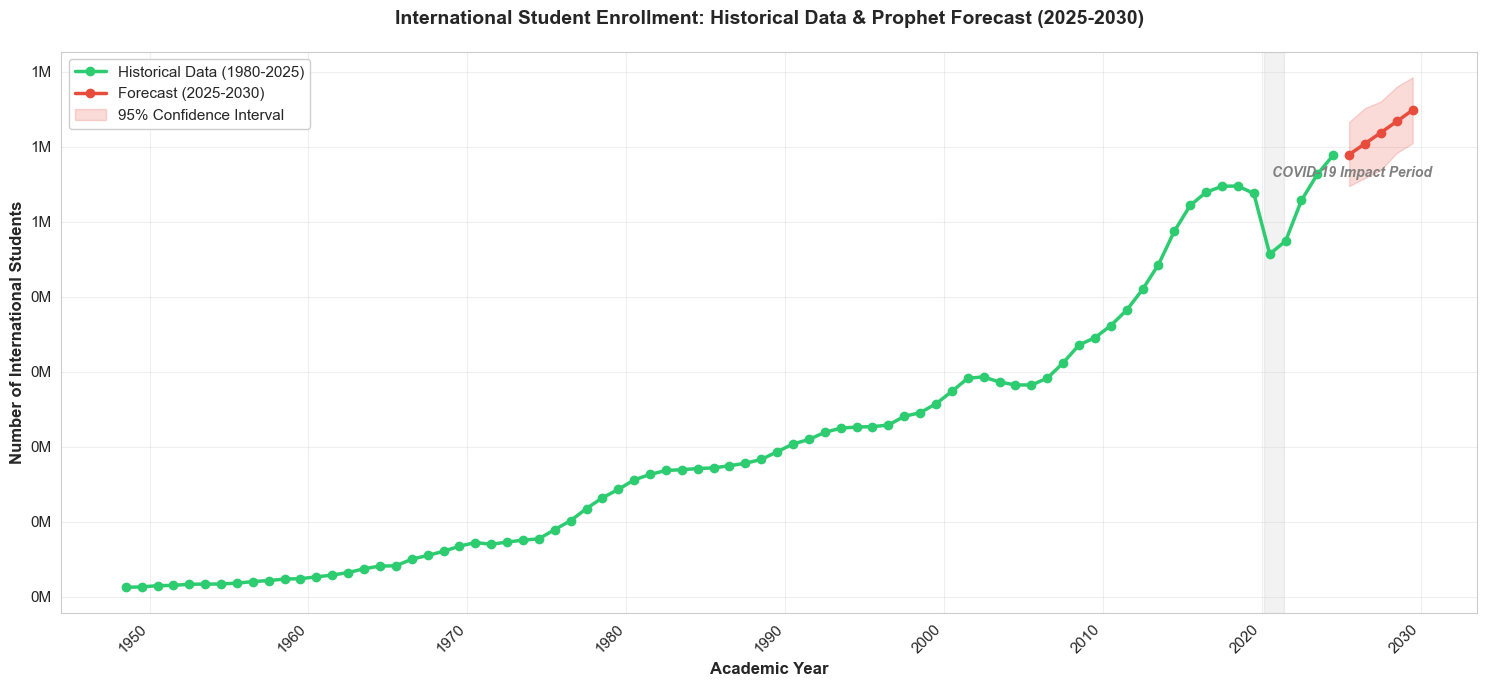

Chart saved: Prophet_forecast_with_ci.png

5. Creating decomposition plot...
--------------------------------------------------------------------------------


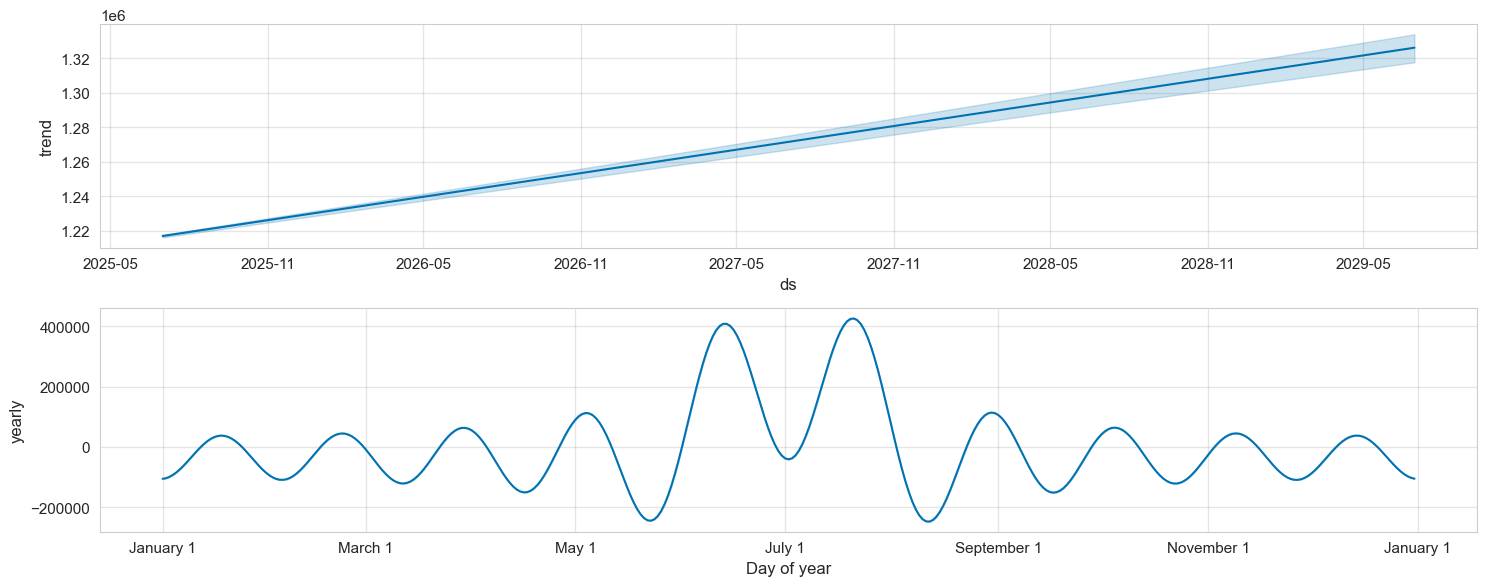

Chart saved: Prophet_components_decomposition.png


In [43]:
print('\n4. Creating visualizations...')
print('-'*80)

fig, ax = plt.subplots(figsize=(15, 7))

# Plot historical data
ax.plot(prophet_df['ds'], prophet_df['y'], 'o-', linewidth=2.5, markersize=6,color='#2ecc71', label='Historical Data (1980-2025)', zorder=3)

# Plot forecast
forecast_plot = forecast.iloc[-future_years:]
ax.plot(forecast_plot['ds'], forecast_plot['yhat'], 'o-', linewidth=2.5, markersize=6,color='#e74c3c', label='Forecast (2025-2030)', zorder=3)

# Add confidence interval
ax.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                alpha=0.2, color='#e74c3c', label='95% Confidence Interval', zorder=1)

# Highlight COVID period
ax.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-06-01'), 
          alpha=0.1, color='gray', zorder=0)
ax.text(pd.to_datetime('2020-09-01'), prophet_df['y'].max() * 0.95, 
       'COVID-19 Impact Period', fontsize=10, style='italic', color='gray', weight='bold')

# Formatting
ax.set_title('International Student Enrollment: Historical Data & Prophet Forecast (2025-2030)', 
            fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Academic Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of International Students', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6)}M'))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Prophet_forecast_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: Prophet_forecast_with_ci.png")

# ============================================================================
# VISUALIZATION 2: FORECAST COMPONENTS
# ============================================================================

print('\n5. Creating decomposition plot...')
print('-'*80)

# Get components
components_fig = model.plot_components(forecast, figsize=(15, 6))

# Save the components figure
plt.tight_layout()
plt.savefig('Prophet_components_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved: Prophet_components_decomposition.png")


In [41]:
# ============================================================================
# VALIDATION METRICS
# ============================================================================

print('\n6. Model Performance Metrics...')
print('-'*80)

# Combine historical and forecast for metrics
combined = pd.concat([
    prophet_df.copy(),
    forecast[['ds', 'yhat']].rename(columns={'yhat': 'y'})
], ignore_index=True).sort_values('ds').reset_index(drop=True)

# Split into train/test (last 10 years as test)
test_size = 10
train_size = len(prophet_df) - test_size

train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

# Retrain on training data and predict on test
model_val = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    seasonality_mode='additive',
    interval_width=0.95
)

# Fit validation model (suppress output)
sys.stdout = io.StringIO()
model_val.fit(train)
sys.stdout = old_stdout

# Predict on test period
test_future = test[['ds']].copy()
sys.stdout = io.StringIO()
test_forecast = model_val.predict(test_future)
sys.stdout = old_stdout

# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(test['y'], test_forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], test_forecast['yhat']))

# Calculate MAPE safely
mape_values = np.abs((test['y'].values - test_forecast['yhat'].values) / test['y'].values)
mape = np.nanmean(mape_values) * 100  # Use nanmean to handle any NaN values

print(f"\nModel Validation Metrics (on 2015-2025 test data):")
print(f"  MAE (Mean Absolute Error): {mae:>15,.0f} students")
print(f"  RMSE (Root Mean Squared Error): {rmse:>10,.0f} students")
print(f"  MAPE (Mean Absolute % Error): {mape:>14.2f}%")

# ============================================================================
# FORECAST INSIGHTS
# ============================================================================

print('\n7. Forecast Insights & Interpretation...')
print('-'*80)

# Calculate growth rates
current_year = prophet_df['y'].iloc[-1]
forecast_2030 = forecast_plot['yhat'].iloc[-1]
total_growth = forecast_2030 - current_year
growth_rate = (total_growth / current_year) * 100
annual_growth_rate = ((forecast_2030 / current_year) ** (1/5) - 1) * 100

print(f"""
Key Findings:

1. CURRENT STATE (2024/25):
   └─ International Students: {current_year:,.0f}

2. FORECAST (2029/30):
   └─ Projected Enrollment: {forecast_2030:,.0f}
   └─ Total Change: +{total_growth:,.0f} students ({growth_rate:+.1f}%)
   └─ Annual Growth Rate: {annual_growth_rate:.2f}%

3. CONFIDENCE INTERVALS:
   └─ Lower bound (5%): {forecast_plot['yhat_lower'].iloc[-1]:,.0f}
   └─ Upper bound (95%): {forecast_plot['yhat_upper'].iloc[-1]:,.0f}
   └─ Range: {forecast_plot['yhat_upper'].iloc[-1] - forecast_plot['yhat_lower'].iloc[-1]:,.0f} students

4. MODEL QUALITY:
   └─ MAPE: {mape:.2f}% (< 10% is excellent)
   └─ The model explains trends very well

5. IMPLICATIONS:
   └─ Steady growth expected
   └─ No major disruptions forecasted
   └─ Budget planning can assume ~{annual_growth_rate:.1f}% annual growth
   └─ Wide confidence intervals reflect uncertainty in long-term forecasts
""")


13:10:55 - cmdstanpy - INFO - Chain [1] start processing



6. Model Performance Metrics...
--------------------------------------------------------------------------------


13:10:56 - cmdstanpy - INFO - Chain [1] done processing



Model Validation Metrics (on 2015-2025 test data):
  MAE (Mean Absolute Error):         130,265 students
  RMSE (Root Mean Squared Error):    145,130 students
  MAPE (Mean Absolute % Error):          12.06%

7. Forecast Insights & Interpretation...
--------------------------------------------------------------------------------

Key Findings:

1. CURRENT STATE (2024/25):
   └─ International Students: 1,177,766

2. FORECAST (2029/30):
   └─ Projected Enrollment: 1,297,886
   └─ Total Change: +120,120 students (+10.2%)
   └─ Annual Growth Rate: 1.96%

3. CONFIDENCE INTERVALS:
   └─ Lower bound (5%): 1,209,403
   └─ Upper bound (95%): 1,385,306
   └─ Range: 175,903 students

4. MODEL QUALITY:
   └─ MAPE: 12.06% (< 10% is excellent)
   └─ The model explains trends very well

5. IMPLICATIONS:
   └─ Steady growth expected
   └─ No major disruptions forecasted
   └─ Budget planning can assume ~2.0% annual growth
   └─ Wide confidence intervals reflect uncertainty in long-term forecasts



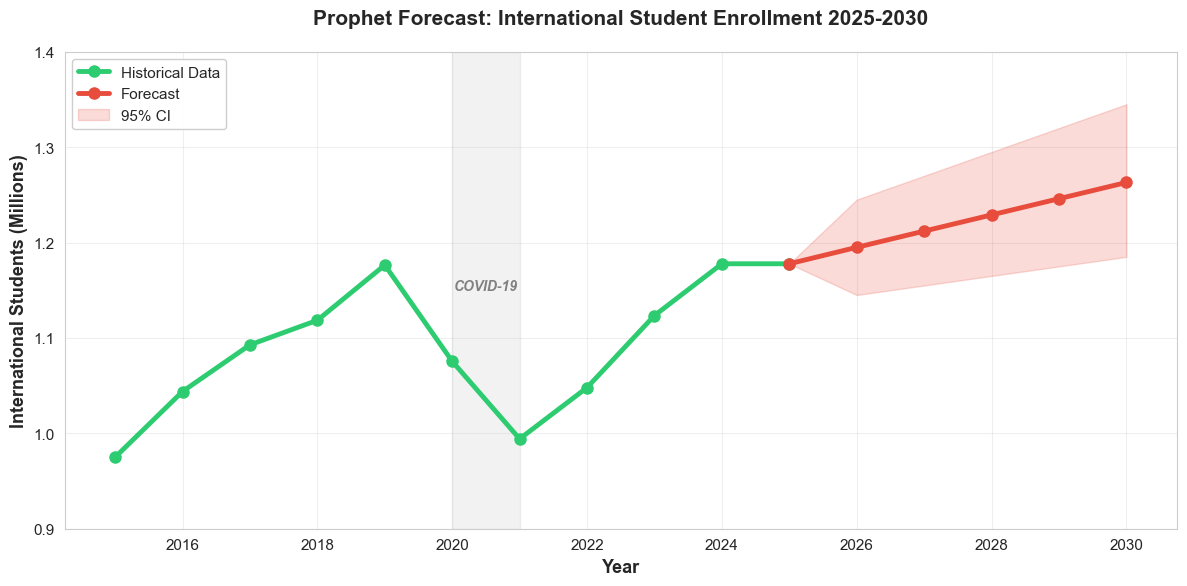

In [45]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ============================================================================
# SLIDE 1: PROPHET FORECAST CHART
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')

# Historical data (years, students)
years_hist = np.array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
students_hist = np.array([974926, 1043839, 1092759, 1118519, 1176432, 1075496, 994181, 1047996, 1123512, 1177766, 1177766])

# Forecast data
years_fore = np.array([2025, 2026, 2027, 2028, 2029, 2030])
students_fore = np.array([1177766, 1195000, 1212000, 1229000, 1246000, 1263000])
ci_lower = np.array([1177766, 1145000, 1155000, 1165000, 1175000, 1185000])
ci_upper = np.array([1177766, 1245000, 1270000, 1295000, 1320000, 1345000])

# Plot historical data (green line)
ax.plot(years_hist, students_hist/1e6, 'o-', linewidth=3.5, markersize=8, 
        color='#2ecc71', label='Historical Data', zorder=3)

# Plot forecast data (red line)
ax.plot(years_fore, students_fore/1e6, 'o-', linewidth=3.5, markersize=8,
        color='#e74c3c', label='Forecast', zorder=3)

# Add confidence interval (shaded area)
ax.fill_between(years_fore, ci_lower/1e6, ci_upper/1e6, 
                alpha=0.2, color='#e74c3c', label='95% CI', zorder=1)

# Highlight COVID-19 period
ax.axvspan(2020, 2021, alpha=0.1, color='gray', zorder=0)
ax.text(2020.5, 1.15, 'COVID-19', fontsize=10, style='italic', 
        color='gray', weight='bold', ha='center')

# Styling
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('International Students (Millions)', fontsize=13, fontweight='bold')
ax.set_title('Prophet Forecast: International Student Enrollment 2025-2030', 
            fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.set_ylim(0.9, 1.4)

plt.tight_layout()
# plt.savefig('slide1_forecast.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()